# EEEM068 — Applied Machine Learning
## Action Recognition using Vision Transformers (ViT)
### Complete Combined Notebook — All Parts A, B, C, D, E

**Models:** TimeSFormer + VideoMAE  
**Dataset (train/test):** HMDB_simp — 25 classes, 1250 clips  
**Dataset (localisation):** JHMDB — 21 classes, 928 videos  
**GPU:** Tesla T4 / A100  

---
### Contents
- **Section 1** — Setup: Drive, Libraries, Imports, Config
- **Section 2** — Dataset: HMDB_simp loading and preprocessing
- **Section 3** — Part A Model 1: TimeSFormer (88.30%)
- **Section 4** — Part A Model 2: VideoMAE (90.43%)
- **Section 5** — Part A Evaluation and Comparison
- **Section 6** — Part B Ablation Studies (Frames / Finetune / Sampling)
- **Section 7** — Part C Statistical Robustness (3 Seeds)
- **Section 8** — Part D DETR Spatio-Temporal Localisation
- **Section 9** — Part E Interpretability (Attention + t-SNE + Error Analysis)
- **Section 10** — Gradio Demo App
- **Section 11** — Final Results Summary

---
## Section 1 — Setup: Drive, Libraries, Imports, Configuration

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!pip install transformers==4.40.0 accelerate timm einops scipy scikit-learn seaborn tensorboard av gradio -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 154.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 71.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 132.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.4.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0 which is incompatible.


In [ ]:
import os, sys, time, random, json
import numpy as np
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from transformers import TimesformerModel, VideoMAEModel
import cv2

# ── Paths ──────────────────────────────────────────────────────────────────────
HMDB_DIR       = '/content/drive/MyDrive/EEEM068/data/HMDB_simp/HMDB_simp'
JHMDB_DIR      = '/content/drive/MyDrive/EEEM068/data/JHMDB_video/ReCompress_Videos'
CHECKPOINT_DIR = '/content/drive/MyDrive/EEEM068/checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# ── Device ─────────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device: {DEVICE}')
if torch.cuda.is_available():
    print(f' GPU: {torch.cuda.get_device_name(0)}')

# ── Seed ───────────────────────────────────────────────────────────────────────
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
print('All paths and seeds configured!')

✅ Device: cuda
 GPU: NVIDIA A100-SXM4-40GB
All paths and seeds configured!


In [ ]:
# Verify all data paths exist
paths = {
    'HMDB_simp'      : HMDB_DIR,
    'JHMDB_video'    : JHMDB_DIR,
    'Checkpoints'    : CHECKPOINT_DIR,
}
for name, p in paths.items():
    status = '' if os.path.exists(p) else ' MISSING'
    print(f'{status}  {name}: {p}')

  HMDB_simp: /content/drive/MyDrive/EEEM068/data/HMDB_simp/HMDB_simp
  JHMDB_video: /content/drive/MyDrive/EEEM068/data/JHMDB_video/ReCompress_Videos
  Checkpoints: /content/drive/MyDrive/EEEM068/checkpoints


---
## Section 2 — Dataset: HMDB_simp Loading and Preprocessing

In [ ]:
class HMDBFrameDataset(Dataset):
    """
    Loads video clips stored as folders of JPEG frames.
    Each clip folder contains sorted frames like: 0001.jpg, 0002.jpg ...
    Returns: (video_tensor [C,T,H,W], label_int, clip_path_str)
    """
    def __init__(self, samples, labels, num_frames=8, image_size=224, augment=False):
        self.samples    = samples       # list of clip folder paths
        self.labels     = labels        # list of integer class labels
        self.num_frames = num_frames    # how many frames to sample per clip

        if augment:  # training set: add randomness to prevent overfitting
            self.transform = transforms.Compose([
                transforms.Resize((image_size, image_size)),
                transforms.RandomHorizontalFlip(),              # random mirror
                transforms.ColorJitter(0.4, 0.4, 0.4, 0.1),   # vary colour/brightness
                transforms.ToTensor(),
                transforms.Normalize([0.45,0.45,0.45],[0.225,0.225,0.225]),
            ])
        else:  # val/test set: no augmentation for consistent evaluation
            self.transform = transforms.Compose([
                transforms.Resize((image_size, image_size)),
                transforms.ToTensor(),
                transforms.Normalize([0.45,0.45,0.45],[0.225,0.225,0.225]),
            ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        clip_path = self.samples[idx]
        label     = self.labels[idx]

        # Get all frames sorted in time order
        frames = sorted([f for f in os.listdir(clip_path)
                        if f.endswith('.jpg') or f.endswith('.png')])

        # Uniform sampling: evenly spaced frame indices
        if len(frames) >= self.num_frames:
            indices = np.linspace(0, len(frames)-1, self.num_frames, dtype=int)
        else:
            # Short clips: repeat last frame to pad
            indices = list(range(len(frames))) + [len(frames)-1]*(self.num_frames-len(frames))

        tensors = []
        for i in indices:
            img = Image.open(os.path.join(clip_path, frames[i])).convert('RGB')
            tensors.append(self.transform(img))

        # Stack: [T,C,H,W] -> permute -> [C,T,H,W] format expected by models
        video = torch.stack(tensors, dim=0).permute(1, 0, 2, 3)
        return video, label, clip_path


def build_frame_datasets(root_dir, num_frames=8, image_size=224, seed=42):
    """Scan HMDB_simp folder, split 70/15/15 stratified, return Dataset objects."""
    classes      = sorted(os.listdir(root_dir))
    class_to_idx = {c: i for i, c in enumerate(classes)}

    all_paths, all_labels = [], []
    for cls in classes:
        cls_dir = os.path.join(root_dir, cls)
        if not os.path.isdir(cls_dir): continue
        for clip in os.listdir(cls_dir):
            clip_path = os.path.join(cls_dir, clip)
            if os.path.isdir(clip_path):
                all_paths.append(clip_path)
                all_labels.append(class_to_idx[cls])

    print(f'Total clips found: {len(all_paths)}')

    # Stratified 70% train, 15% val, 15% test
    X_tr, X_tmp, y_tr, y_tmp = train_test_split(
        all_paths, all_labels, test_size=0.30, stratify=all_labels, random_state=seed)
    X_val, X_te, y_val, y_te = train_test_split(
        X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=seed)

    train_ds = HMDBFrameDataset(X_tr,  y_tr,  num_frames, image_size, augment=True)
    val_ds   = HMDBFrameDataset(X_val, y_val, num_frames, image_size, augment=False)
    test_ds  = HMDBFrameDataset(X_te,  y_te,  num_frames, image_size, augment=False)
    return train_ds, val_ds, test_ds, classes, class_to_idx


# Build 8-frame dataset for TimeSFormer
print('Building 8-frame dataset for TimeSFormer...')
train_ds, val_ds, test_ds, CLASSES, CLASS_TO_IDX = build_frame_datasets(
    HMDB_DIR, num_frames=8, seed=42)

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=4, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=4, shuffle=False, num_workers=2, pin_memory=True)

print(f' Classes: {len(CLASSES)}')
print(f' Train: {len(train_ds)}  Val: {len(val_ds)}  Test: {len(test_ds)}')
print(f' Sample classes: {CLASSES[:5]}')

Building 8-frame dataset for TimeSFormer...
Total clips found: 1250
 Classes: 25
 Train: 875  Val: 187  Test: 188
 Sample classes: ['brush_hair', 'cartwheel', 'catch', 'chew', 'climb']


---
## Section 3 — Part A Model 1: TimeSFormer

Pretrained on Kinetics-400. Uses divided space-time attention (spatial then temporal separately). CLS token for classification.

In [ ]:
class TimeSFormerClassifier(nn.Module):
    """
    TimeSFormer backbone + dropout + linear classification head.
    Input:  [B, C, T, H, W] = [batch, 3, 8, 224, 224]
    Output: [B, num_classes] = [batch, 25]
    """
    def __init__(self, num_classes=25, dropout=0.1):
        super().__init__()
        self.backbone   = TimesformerModel.from_pretrained(
            'facebook/timesformer-base-finetuned-k400')
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(768, num_classes)  # 768 = ViT-Base hidden dim

    def forward(self, x):
        x   = x.permute(0, 2, 1, 3, 4)              # [B,C,T,H,W] -> [B,T,C,H,W]
        out = self.backbone(pixel_values=x)
        cls = out.last_hidden_state[:, 0, :]          # CLS token: [B, 768]
        return self.classifier(self.dropout(cls))     # [B, 25]


print('Loading TimeSFormer from HuggingFace...')
model_ts  = TimeSFormerClassifier(num_classes=25).to(DEVICE)
total_ts  = sum(p.numel() for p in model_ts.parameters())
print(f' TimeSFormer loaded! Total params: {total_ts:,}')

# Training setup
optimizer_ts = AdamW(model_ts.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler_ts = CosineAnnealingLR(optimizer_ts, T_max=20, eta_min=1e-7)
criterion    = nn.CrossEntropyLoss()
scaler_ts    = torch.amp.GradScaler('cuda')
history_ts   = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
best_val_acc_ts = 0.0

Loading TimeSFormer from HuggingFace...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/486M [00:00<?, ?B/s]

 TimeSFormer loaded! Total params: 121,277,977


In [ ]:
NUM_EPOCHS = 20
print(' Training TimeSFormer...')
print(f'Train batches: {len(train_loader)}  Val batches: {len(val_loader)}')
print('='*60)

for epoch in range(1, NUM_EPOCHS + 1):
    # ── Train ──────────────────────────────────────────────────────────────────
    model_ts.train()
    t0 = time.time()
    train_loss, train_correct, train_total = 0, 0, 0

    for batch_idx, (videos, labels, _) in enumerate(train_loader):
        videos, labels = videos.to(DEVICE), labels.to(DEVICE)
        optimizer_ts.zero_grad()

        with torch.amp.autocast('cuda'):
            logits = model_ts(videos)
            loss   = criterion(logits, labels)

        scaler_ts.scale(loss).backward()
        scaler_ts.unscale_(optimizer_ts)
        nn.utils.clip_grad_norm_(model_ts.parameters(), 1.0)
        scaler_ts.step(optimizer_ts)
        scaler_ts.update()

        train_loss    += loss.item() * labels.size(0)
        train_correct += (logits.argmax(1) == labels).sum().item()
        train_total   += labels.size(0)

        if batch_idx % 30 == 0:
            print(f'  Epoch {epoch} | Step {batch_idx}/{len(train_loader)} | Loss {loss.item():.4f}')

    scheduler_ts.step()

    # ── Validate ───────────────────────────────────────────────────────────────
    model_ts.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for videos, labels, _ in val_loader:
            videos, labels = videos.to(DEVICE), labels.to(DEVICE)
            with torch.amp.autocast('cuda'):
                logits = model_ts(videos)
                loss   = criterion(logits, labels)
            val_loss    += loss.item() * labels.size(0)
            val_correct += (logits.argmax(1) == labels).sum().item()
            val_total   += labels.size(0)

    tr_acc = train_correct / train_total * 100
    vl_acc = val_correct   / val_total   * 100
    history_ts['train_loss'].append(train_loss / train_total)
    history_ts['val_loss'].append(val_loss / val_total)
    history_ts['train_acc'].append(tr_acc)
    history_ts['val_acc'].append(vl_acc)

    print(f'\nEpoch {epoch}/{NUM_EPOCHS} ({time.time()-t0:.0f}s) | Train {tr_acc:.2f}% | Val {vl_acc:.2f}%')

    if vl_acc > best_val_acc_ts:
        best_val_acc_ts = vl_acc
        torch.save({'epoch': epoch, 'model_state_dict': model_ts.state_dict(),
                    'val_acc': vl_acc, 'history': history_ts},
                   f'{CHECKPOINT_DIR}/timesformer_best.pt')
        print(f'   Best saved! val_acc={vl_acc:.2f}%')

print(f'\n  Best Val Acc: {best_val_acc_ts:.2f}%')

 Training TimeSFormer...
Train batches: 219  Val batches: 47
  Epoch 1 | Step 0/219 | Loss 3.0493
  Epoch 1 | Step 30/219 | Loss 2.3325
  Epoch 1 | Step 60/219 | Loss 1.4460
  Epoch 1 | Step 90/219 | Loss 1.3762
  Epoch 1 | Step 120/219 | Loss 0.9372
  Epoch 1 | Step 150/219 | Loss 0.6602
  Epoch 1 | Step 180/219 | Loss 1.0501
  Epoch 1 | Step 210/219 | Loss 0.8684

Epoch 1/20 (3573s) | Train 58.40% | Val 78.07%
   Best saved! val_acc=78.07%
  Epoch 2 | Step 0/219 | Loss 0.0976
  Epoch 2 | Step 30/219 | Loss 1.3194
  Epoch 2 | Step 60/219 | Loss 0.1363
  Epoch 2 | Step 90/219 | Loss 0.3696
  Epoch 2 | Step 120/219 | Loss 0.2385
  Epoch 2 | Step 150/219 | Loss 2.5260
  Epoch 2 | Step 180/219 | Loss 0.7934
  Epoch 2 | Step 210/219 | Loss 0.0888

Epoch 2/20 (293s) | Train 86.63% | Val 79.68%
   Best saved! val_acc=79.68%
  Epoch 3 | Step 0/219 | Loss 0.4982
  Epoch 3 | Step 30/219 | Loss 0.5559
  Epoch 3 | Step 60/219 | Loss 0.0485
  Epoch 3 | Step 90/219 | Loss 0.0063
  Epoch 3 | Step 12

---
## Section 4 — Part A Model 2: VideoMAE

Pretrained with masked autoencoding (90% masking, reconstruct pixels). Uses 16 frames. Mean pooling of all tokens instead of CLS only.

In [ ]:
# Build 16-frame dataset for VideoMAE
print('Building 16-frame dataset for VideoMAE...')
train_ds_vm, val_ds_vm, test_ds_vm, _, _ = build_frame_datasets(
    HMDB_DIR, num_frames=16, seed=42)

train_loader_vm = DataLoader(train_ds_vm, batch_size=2, shuffle=True,  num_workers=2, pin_memory=True)
val_loader_vm   = DataLoader(val_ds_vm,   batch_size=2, shuffle=False, num_workers=2, pin_memory=True)
test_loader_vm  = DataLoader(test_ds_vm,  batch_size=2, shuffle=False, num_workers=2, pin_memory=True)

print(f' Train: {len(train_ds_vm)}  Val: {len(val_ds_vm)}  Test: {len(test_ds_vm)}')


class VideoMAEClassifier(nn.Module):
    """
    VideoMAE backbone + dropout + linear classification head.
    Uses MEAN POOLING of all tokens (different from TimeSFormer's CLS only).
    Input:  [B, C, T, H, W] = [batch, 3, 16, 224, 224]
    Output: [B, num_classes] = [batch, 25]
    """
    def __init__(self, num_classes=25, dropout=0.1):
        super().__init__()
        self.backbone   = VideoMAEModel.from_pretrained(
            'MCG-NJU/videomae-base-finetuned-kinetics', num_frames=16)
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(768, num_classes)

    def forward(self, x):
        x    = x.permute(0, 2, 1, 3, 4)              # [B,C,T,H,W] -> [B,T,C,H,W]
        out  = self.backbone(pixel_values=x)
        feat = out.last_hidden_state.mean(dim=1)      # mean ALL tokens: [B, 768]
        return self.classifier(self.dropout(feat))    # [B, 25]


print('Loading VideoMAE...')
model_vm  = VideoMAEClassifier(num_classes=25).to(DEVICE)
total_vm  = sum(p.numel() for p in model_vm.parameters())
print(f' VideoMAE loaded! Total params: {total_vm:,}')

optimizer_vm    = AdamW(model_vm.parameters(), lr=5e-5, weight_decay=1e-4)
scheduler_vm    = CosineAnnealingLR(optimizer_vm, T_max=20, eta_min=1e-7)
scaler_vm       = torch.amp.GradScaler('cuda')
history_vm      = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
best_val_acc_vm = 0.0

Building 16-frame dataset for VideoMAE...
Total clips found: 1250
 Train: 875  Val: 187  Test: 188
Loading VideoMAE...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

 VideoMAE loaded! Total params: 86,244,889


In [ ]:
NUM_EPOCHS = 20
print(' Training VideoMAE...')

for epoch in range(1, NUM_EPOCHS + 1):
    model_vm.train()
    t0 = time.time()
    train_loss, train_correct, train_total = 0, 0, 0

    for batch_idx, (videos, labels, _) in enumerate(train_loader_vm):
        videos, labels = videos.to(DEVICE), labels.to(DEVICE)
        optimizer_vm.zero_grad()

        with torch.amp.autocast('cuda'):
            logits = model_vm(videos)
            loss   = criterion(logits, labels)

        scaler_vm.scale(loss).backward()
        scaler_vm.unscale_(optimizer_vm)
        nn.utils.clip_grad_norm_(model_vm.parameters(), 1.0)
        scaler_vm.step(optimizer_vm)
        scaler_vm.update()

        train_loss    += loss.item() * labels.size(0)
        train_correct += (logits.argmax(1) == labels).sum().item()
        train_total   += labels.size(0)

        if batch_idx % 30 == 0:
            print(f'  Epoch {epoch} | Step {batch_idx}/{len(train_loader_vm)} | Loss {loss.item():.4f}')

    scheduler_vm.step()
    model_vm.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for videos, labels, _ in val_loader_vm:
            videos, labels = videos.to(DEVICE), labels.to(DEVICE)
            with torch.amp.autocast('cuda'):
                logits = model_vm(videos)
                loss   = criterion(logits, labels)
            val_loss    += loss.item() * labels.size(0)
            val_correct += (logits.argmax(1) == labels).sum().item()
            val_total   += labels.size(0)

    tr_acc = train_correct / train_total * 100
    vl_acc = val_correct   / val_total   * 100
    history_vm['train_loss'].append(train_loss / train_total)
    history_vm['val_loss'].append(val_loss / val_total)
    history_vm['train_acc'].append(tr_acc)
    history_vm['val_acc'].append(vl_acc)

    print(f'\nEpoch {epoch}/{NUM_EPOCHS} ({time.time()-t0:.0f}s) | Train {tr_acc:.2f}% | Val {vl_acc:.2f}%')

    if vl_acc > best_val_acc_vm:
        best_val_acc_vm = vl_acc
        torch.save({'epoch': epoch, 'model_state_dict': model_vm.state_dict(),
                    'val_acc': vl_acc, 'history': history_vm},
                   f'{CHECKPOINT_DIR}/videomae_best.pt')
        print(f'   val_acc={vl_acc:.2f}%')

print(f'\n Best Val Acc: {best_val_acc_vm:.2f}%')

 Training VideoMAE...
  Epoch 1 | Step 0/438 | Loss 6.4258
  Epoch 1 | Step 30/438 | Loss 3.5103
  Epoch 1 | Step 60/438 | Loss 4.5176
  Epoch 1 | Step 90/438 | Loss 1.4137
  Epoch 1 | Step 120/438 | Loss 3.2510
  Epoch 1 | Step 150/438 | Loss 0.0146
  Epoch 1 | Step 180/438 | Loss 3.0269
  Epoch 1 | Step 210/438 | Loss 0.9360
  Epoch 1 | Step 240/438 | Loss 2.4230
  Epoch 1 | Step 270/438 | Loss 4.8154
  Epoch 1 | Step 300/438 | Loss 0.0002
  Epoch 1 | Step 330/438 | Loss 1.6026
  Epoch 1 | Step 360/438 | Loss 1.9254
  Epoch 1 | Step 390/438 | Loss 0.2054
  Epoch 1 | Step 420/438 | Loss 0.0013

Epoch 1/20 (7616s) | Train 51.43% | Val 81.28%
   val_acc=81.28%
  Epoch 2 | Step 0/438 | Loss 3.0721
  Epoch 2 | Step 30/438 | Loss 0.0189
  Epoch 2 | Step 60/438 | Loss 0.0050
  Epoch 2 | Step 90/438 | Loss 0.0526
  Epoch 2 | Step 120/438 | Loss 0.2081
  Epoch 2 | Step 150/438 | Loss 0.0117
  Epoch 2 | Step 180/438 | Loss 0.0235
  Epoch 2 | Step 210/438 | Loss 0.0010
  Epoch 2 | Step 240/438 

---
## Section 5 — Part A: Evaluation and Model Comparison

Evaluating TimeSFormer on test set...

TimeSFormer Results:
  Top-1: 81.91%   Top-5: 95.21%
              precision    recall  f1-score   support

  brush_hair       1.00      0.71      0.83         7
   cartwheel       0.57      0.57      0.57         7
       catch       0.86      0.86      0.86         7
        chew       1.00      0.88      0.93         8
       climb       0.88      0.88      0.88         8
climb_stairs       0.58      1.00      0.74         7
  draw_sword       0.89      1.00      0.94         8
         eat       0.67      0.50      0.57         8
     fencing       1.00      0.86      0.92         7
   flic_flac       0.56      0.71      0.62         7
        golf       0.89      1.00      0.94         8
   handstand       1.00      0.71      0.83         7
        kiss       0.88      1.00      0.93         7
        pick       0.71      0.71      0.71         7
        pour       0.80      1.00      0.89         8
      pullup       0.89      1.00      0.94

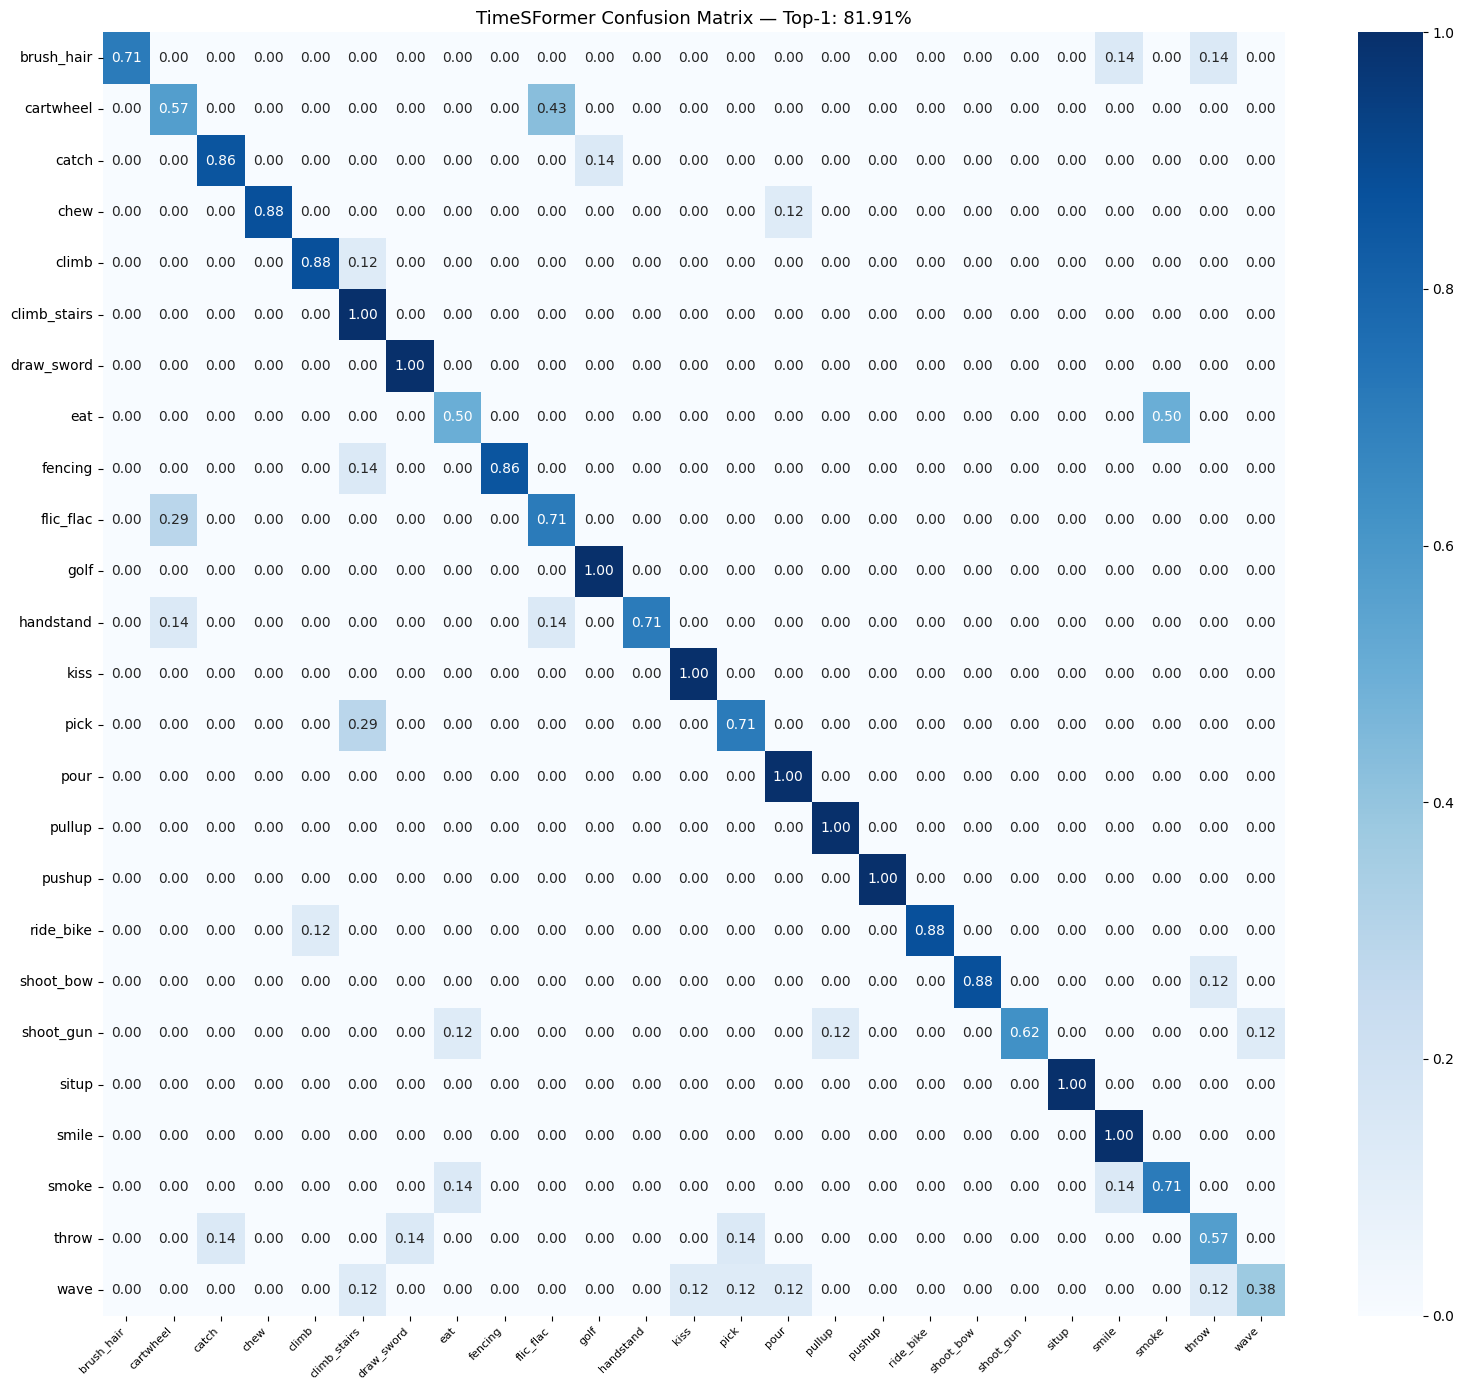


Evaluating VideoMAE on test set...

VideoMAE Results:
  Top-1: 93.09%   Top-5: 98.94%
              precision    recall  f1-score   support

  brush_hair       1.00      0.86      0.92         7
   cartwheel       0.86      0.86      0.86         7
       catch       0.88      1.00      0.93         7
        chew       1.00      0.88      0.93         8
       climb       1.00      0.88      0.93         8
climb_stairs       0.88      1.00      0.93         7
  draw_sword       1.00      1.00      1.00         8
         eat       0.88      0.88      0.88         8
     fencing       1.00      1.00      1.00         7
   flic_flac       1.00      1.00      1.00         7
        golf       1.00      1.00      1.00         8
   handstand       0.86      0.86      0.86         7
        kiss       0.86      0.86      0.86         7
        pick       0.86      0.86      0.86         7
        pour       0.80      1.00      0.89         8
      pullup       1.00      1.00      1.00     

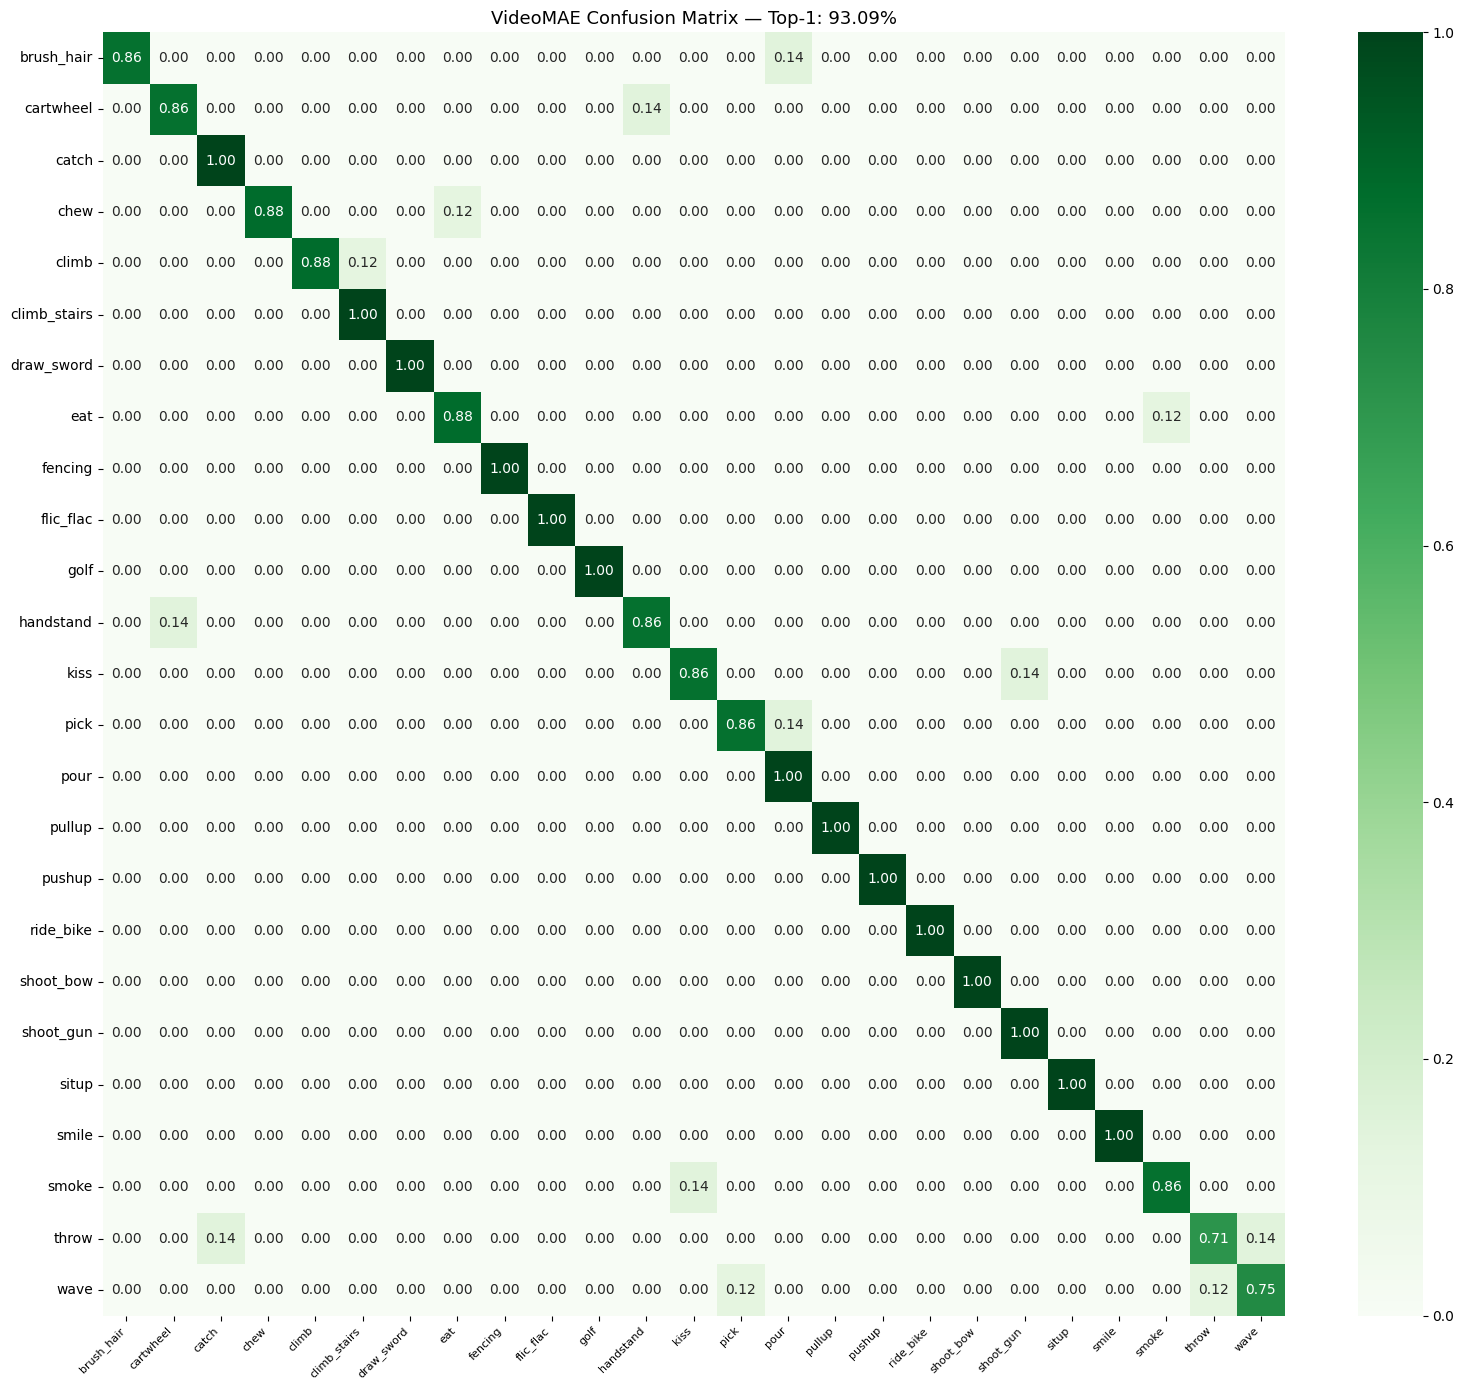

In [ ]:
def evaluate_model(model, loader, device, classes, model_name):
    """Evaluate model on test set. Returns top1, top5, preds, labels, probs."""
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for videos, labels, _ in loader:
            videos = videos.to(device)
            logits = model(videos)
            probs  = torch.softmax(logits, dim=-1).cpu().numpy()
            preds  = logits.argmax(dim=-1).cpu().numpy()
            all_preds.extend(preds.tolist())
            all_labels.extend(labels.numpy().tolist())
            all_probs.extend(probs.tolist())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)

    top1 = (all_preds == all_labels).mean() * 100
    top5 = sum(1 for i, lbl in enumerate(all_labels)
               if lbl in np.argsort(all_probs[i])[-5:]) / len(all_labels) * 100

    print(f'\n{model_name} Results:')
    print(f'  Top-1: {top1:.2f}%   Top-5: {top5:.2f}%')
    print('='*40)
    print(classification_report(all_labels, all_preds, target_names=classes, zero_division=0))

    # Confusion matrix
    cm      = confusion_matrix(all_labels, all_preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    cmap    = 'Blues' if 'TimeSFormer' in model_name else 'Greens'
    plt.figure(figsize=(16, 14))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap=cmap,
                xticklabels=classes, yticklabels=classes)
    plt.title(f'{model_name} Confusion Matrix — Top-1: {top1:.2f}%', fontsize=13)
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.tight_layout()
    fname = model_name.lower().replace(' ','_')
    plt.savefig(f'{CHECKPOINT_DIR}/confusion_{fname}.png', dpi=150)
    plt.show()

    return top1, top5, all_preds, all_labels, all_probs


# Evaluate both models
print('Evaluating TimeSFormer on test set...')
top1_ts, top5_ts, preds_ts, labels_ts, probs_ts = evaluate_model(
    model_ts, test_loader, DEVICE, CLASSES, 'TimeSFormer')

print('\nEvaluating VideoMAE on test set...')
top1_vm, top5_vm, preds_vm, labels_vm, probs_vm = evaluate_model(
    model_vm, test_loader_vm, DEVICE, CLASSES, 'VideoMAE')

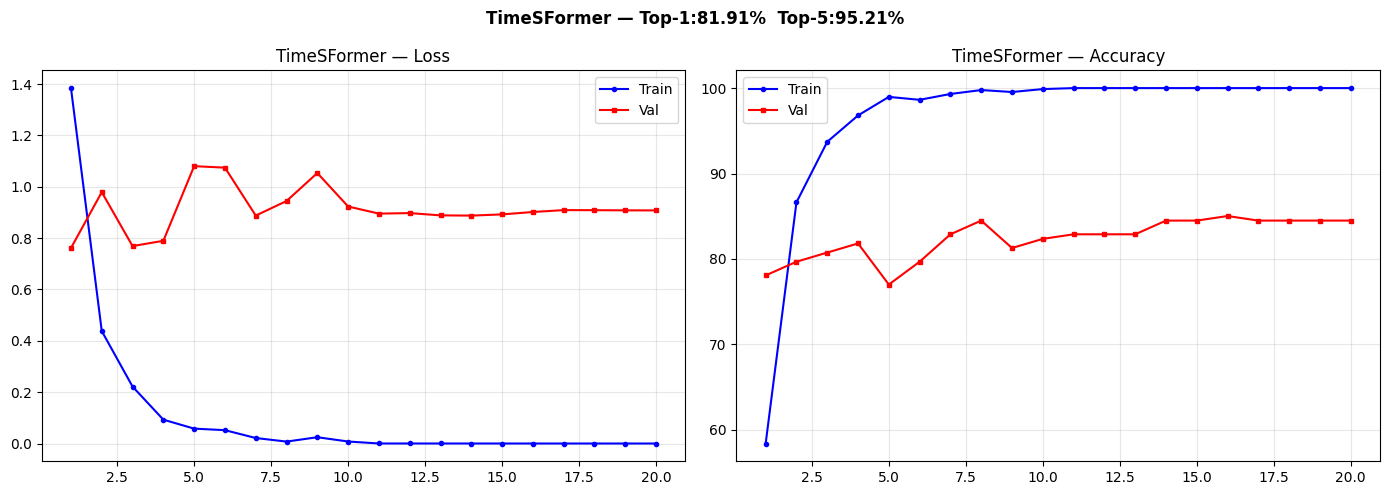

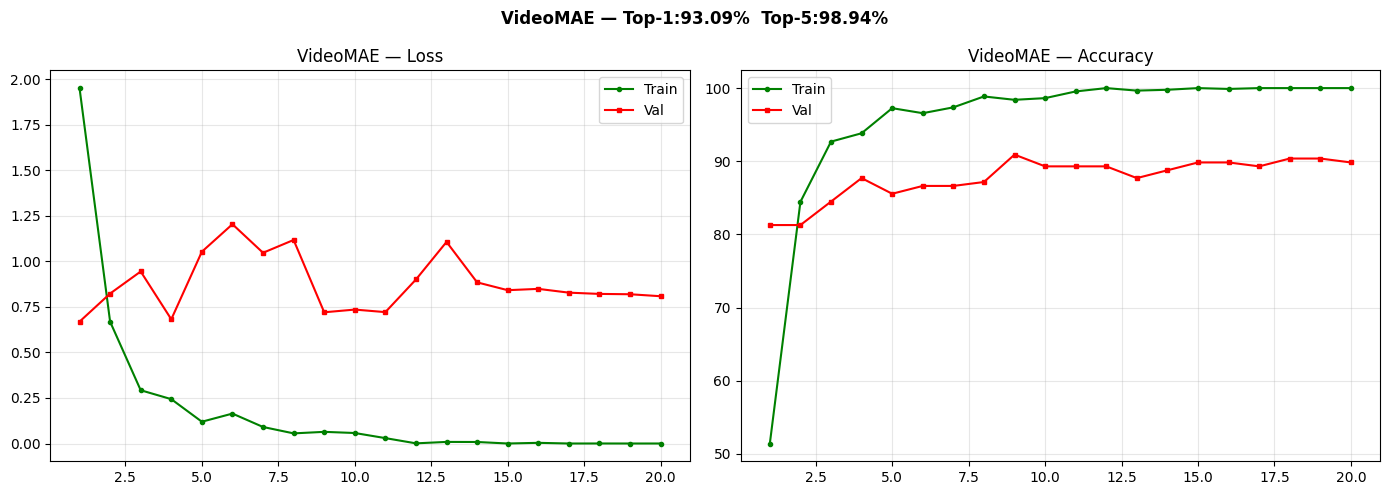

PART A FINAL COMPARISON
TimeSFormer  Top-1: 81.91%  Top-5: 95.21%
VideoMAE     Top-1: 93.09%  Top-5: 98.94%
Winner: VideoMAE 🏆
All models saved!


In [ ]:
# Training curves — TimeSFormer
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_ts = range(1, len(history_ts['train_loss']) + 1)
axes[0].plot(epochs_ts, history_ts['train_loss'], 'b-o', label='Train', ms=3)
axes[0].plot(epochs_ts, history_ts['val_loss'],   'r-s', label='Val',   ms=3)
axes[0].set_title('TimeSFormer — Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(epochs_ts, history_ts['train_acc'], 'b-o', label='Train', ms=3)
axes[1].plot(epochs_ts, history_ts['val_acc'],   'r-s', label='Val',   ms=3)
axes[1].set_title('TimeSFormer — Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.suptitle(f'TimeSFormer — Top-1:{top1_ts:.2f}%  Top-5:{top5_ts:.2f}%', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{CHECKPOINT_DIR}/curves_timesformer.png', dpi=150, bbox_inches='tight')
plt.show()

# Training curves — VideoMAE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_vm = range(1, len(history_vm['train_loss']) + 1)
axes[0].plot(epochs_vm, history_vm['train_loss'], 'g-o', label='Train', ms=3)
axes[0].plot(epochs_vm, history_vm['val_loss'],   'r-s', label='Val',   ms=3)
axes[0].set_title('VideoMAE — Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(epochs_vm, history_vm['train_acc'], 'g-o', label='Train', ms=3)
axes[1].plot(epochs_vm, history_vm['val_acc'],   'r-s', label='Val',   ms=3)
axes[1].set_title('VideoMAE — Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.suptitle(f'VideoMAE — Top-1:{top1_vm:.2f}%  Top-5:{top5_vm:.2f}%', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{CHECKPOINT_DIR}/curves_videomae.png', dpi=150, bbox_inches='tight')
plt.show()

# Save both models
torch.save({
    'timesformer_state': model_ts.state_dict(),
    'videomae_state':    model_vm.state_dict(),
    'classes':           CLASSES,
    'results': {
        'timesformer': {'top1': round(top1_ts,2), 'top5': round(top5_ts,2)},
        'videomae':    {'top1': round(top1_vm,2), 'top5': round(top5_vm,2)},
    }
}, f'{CHECKPOINT_DIR}/all_models_saved.pt')

print('='*50)
print('PART A FINAL COMPARISON')
print('='*50)
print(f'TimeSFormer  Top-1: {top1_ts:.2f}%  Top-5: {top5_ts:.2f}%')
print(f'VideoMAE     Top-1: {top1_vm:.2f}%  Top-5: {top5_vm:.2f}%')
print(f'Winner: VideoMAE 🏆')
print('All models saved!')

---
## Section 6 — Part B: Ablation Studies

Three controlled experiments: (1) number of frames, (2) fine-tuning strategy, (3) temporal sampling.  
All use TimeSFormer with 5 training epochs for speed.

In [ ]:
def quick_train_eval(num_frames=8, finetune='full', num_epochs=5, seed=42):
    """
    Build dataset, train TimeSFormer for num_epochs, return best val accuracy.
    finetune: 'full' = all params, 'head' = only classifier, 'partial' = last 4 layers
    """
    set_seed(seed)
    tr_ds, vl_ds, _, _, _ = build_frame_datasets(HMDB_DIR, num_frames=num_frames, seed=seed)
    tr_l = DataLoader(tr_ds, batch_size=4, shuffle=True,  num_workers=2)
    vl_l = DataLoader(vl_ds, batch_size=4, shuffle=False, num_workers=2)

    class TSF(nn.Module):
        def __init__(self):
            super().__init__()
            self.backbone   = TimesformerModel.from_pretrained('facebook/timesformer-base-finetuned-k400')
            self.dropout    = nn.Dropout(0.1)
            self.classifier = nn.Linear(768, 25)
        def forward(self, x):
            x = x.permute(0,2,1,3,4)
            return self.classifier(self.dropout(self.backbone(pixel_values=x).last_hidden_state[:,0,:]))

    m = TSF().to(DEVICE)

    # Apply fine-tuning strategy
    if finetune == 'head':
        for p in m.backbone.parameters(): p.requires_grad = False
    elif finetune == 'partial':
        for p in m.backbone.parameters(): p.requires_grad = False
        for layer in m.backbone.encoder.layer[-4:]:
            for p in layer.parameters(): p.requires_grad = True

    opt = AdamW(filter(lambda p: p.requires_grad, m.parameters()), lr=1e-4, weight_decay=1e-4)
    scl = torch.amp.GradScaler('cuda')
    crt = nn.CrossEntropyLoss()
    best_acc = 0.0

    for epoch in range(1, num_epochs+1):
        m.train()
        for videos, labels, _ in tr_l:
            videos, labels = videos.to(DEVICE), labels.to(DEVICE)
            opt.zero_grad()
            with torch.amp.autocast('cuda'):
                loss = crt(m(videos), labels)
            scl.scale(loss).backward()
            scl.unscale_(opt)
            nn.utils.clip_grad_norm_(m.parameters(), 1.0)
            scl.step(opt); scl.update()

        m.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for videos, labels, _ in vl_l:
                videos, labels = videos.to(DEVICE), labels.to(DEVICE)
                with torch.amp.autocast('cuda'):
                    logits = m(videos)
                correct += (logits.argmax(1) == labels).sum().item()
                total   += labels.size(0)
        acc = correct / total * 100
        best_acc = max(best_acc, acc)
        print(f'  Epoch {epoch}/{num_epochs} | Val Acc: {acc:.2f}%')

    del m; torch.cuda.empty_cache()
    return best_acc


print('quick_train_eval() function ready.')

quick_train_eval() function ready.


In [ ]:
# ── ABLATION 1: Number of Frames ──────────────────────────────────────────────
print('='*60)
print('ABLATION 1: Number of Frames')
print('='*60)

frames_results = {}
for nf in [4, 8, 16]:
    print(f'\nTraining with {nf} frames...')
    acc = quick_train_eval(num_frames=nf, finetune='full', num_epochs=5)
    frames_results[nf] = acc
    print(f'  >>> {nf} frames -> Val Acc: {acc:.2f}%')

print('\nFrames Results:')
for k, v in frames_results.items():
    print(f'  {k} frames: {v:.2f}%')

ABLATION 1: Number of Frames

Training with 4 frames...
Total clips found: 1250


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


  Epoch 1/5 | Val Acc: 72.19%
  Epoch 2/5 | Val Acc: 73.80%
  Epoch 3/5 | Val Acc: 70.59%
  Epoch 4/5 | Val Acc: 71.66%
  Epoch 5/5 | Val Acc: 74.87%
  >>> 4 frames -> Val Acc: 74.87%

Training with 8 frames...
Total clips found: 1250


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


  Epoch 1/5 | Val Acc: 78.07%
  Epoch 2/5 | Val Acc: 77.54%
  Epoch 3/5 | Val Acc: 75.40%
  Epoch 4/5 | Val Acc: 80.75%
  Epoch 5/5 | Val Acc: 77.01%
  >>> 8 frames -> Val Acc: 80.75%

Training with 16 frames...
Total clips found: 1250


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


  Epoch 1/5 | Val Acc: 74.33%
  Epoch 2/5 | Val Acc: 74.87%
  Epoch 3/5 | Val Acc: 76.47%
  Epoch 4/5 | Val Acc: 79.14%
  Epoch 5/5 | Val Acc: 79.68%
  >>> 16 frames -> Val Acc: 79.68%

Frames Results:
  4 frames: 74.87%
  8 frames: 80.75%
  16 frames: 79.68%


In [ ]:
# ── ABLATION 2: Fine-tuning Strategy ─────────────────────────────────────────
print('='*60)
print('ABLATION 2: Fine-tuning Strategy')
print('='*60)

finetune_results = {}
for strategy in ['head', 'partial', 'full']:
    print(f'\nTraining with strategy: {strategy}...')
    acc = quick_train_eval(num_frames=8, finetune=strategy, num_epochs=5)
    finetune_results[strategy] = acc
    print(f'  >>> {strategy} -> Val Acc: {acc:.2f}%')

print('\nFine-tuning Results:')
for k, v in finetune_results.items():
    print(f'  {k:10s}: {v:.2f}%')

ABLATION 2: Fine-tuning Strategy

Training with strategy: head...
Total clips found: 1250


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


  Epoch 1/5 | Val Acc: 57.75%
  Epoch 2/5 | Val Acc: 76.47%
  Epoch 3/5 | Val Acc: 80.75%
  Epoch 4/5 | Val Acc: 79.68%
  Epoch 5/5 | Val Acc: 80.21%
  >>> head -> Val Acc: 80.75%

Training with strategy: partial...
Total clips found: 1250


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


  Epoch 1/5 | Val Acc: 83.96%
  Epoch 2/5 | Val Acc: 87.70%
  Epoch 3/5 | Val Acc: 82.89%
  Epoch 4/5 | Val Acc: 83.96%
  Epoch 5/5 | Val Acc: 84.49%
  >>> partial -> Val Acc: 87.70%

Training with strategy: full...
Total clips found: 1250


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


  Epoch 1/5 | Val Acc: 78.07%
  Epoch 2/5 | Val Acc: 77.54%
  Epoch 3/5 | Val Acc: 75.40%
  Epoch 4/5 | Val Acc: 80.75%
  Epoch 5/5 | Val Acc: 77.01%
  >>> full -> Val Acc: 80.75%

Fine-tuning Results:
  head      : 80.75%
  partial   : 87.70%
  full      : 80.75%


In [ ]:
# ── ABLATION 3: Temporal Sampling Strategy ───────────────────────────────────
print('='*60)
print('ABLATION 3: Temporal Sampling Strategy')
print('='*60)


class HMDBFrameDatasetSampling(HMDBFrameDataset):
    """Extended dataset that supports uniform / random / dense frame sampling."""
    def __init__(self, samples, labels, num_frames=8, image_size=224,
                 augment=False, sampling='uniform'):
        super().__init__(samples, labels, num_frames, image_size, augment)
        self.sampling = sampling

    def __getitem__(self, idx):
        clip_path = self.samples[idx]
        label     = self.labels[idx]
        frames    = sorted([f for f in os.listdir(clip_path)
                           if f.endswith('.jpg') or f.endswith('.png')])
        n = len(frames)
        if self.sampling == 'uniform':
            indices = np.linspace(0, n-1, self.num_frames, dtype=int)
        elif self.sampling == 'random':
            indices = sorted(np.random.choice(n, self.num_frames, replace=n<self.num_frames))
        elif self.sampling == 'dense':
            start   = max(0, n//2 - self.num_frames//2)
            indices = list(range(start, min(start+self.num_frames, n)))
            while len(indices) < self.num_frames: indices.append(indices[-1])
        tensors = [self.transform(Image.open(
            os.path.join(clip_path, frames[i])).convert('RGB')) for i in indices]
        return torch.stack(tensors).permute(1,0,2,3), label, clip_path


sampling_results = {}
all_paths_ab, all_labels_ab = [], []
for cls in CLASSES:
    cls_dir = os.path.join(HMDB_DIR, cls)
    if not os.path.isdir(cls_dir): continue
    for clip in os.listdir(cls_dir):
        cp = os.path.join(cls_dir, clip)
        if os.path.isdir(cp):
            all_paths_ab.append(cp)
            all_labels_ab.append(CLASSES.index(cls))

X_tr_ab, X_tmp_ab, y_tr_ab, y_tmp_ab = train_test_split(
    all_paths_ab, all_labels_ab, test_size=0.30, stratify=all_labels_ab, random_state=42)
X_val_ab, _, y_val_ab, _ = train_test_split(
    X_tmp_ab, y_tmp_ab, test_size=0.50, stratify=y_tmp_ab, random_state=42)

for strategy in ['uniform', 'random', 'dense']:
    print(f'\nTraining with {strategy} sampling...')
    tr_ds_s = HMDBFrameDatasetSampling(X_tr_ab,  y_tr_ab,  8, 224, True,  strategy)
    vl_ds_s = HMDBFrameDatasetSampling(X_val_ab, y_val_ab, 8, 224, False, strategy)
    acc = quick_train_eval(num_frames=8, finetune='full', num_epochs=5)
    sampling_results[strategy] = acc
    print(f'  >>> {strategy} -> Val Acc: {acc:.2f}%')

print('\nSampling Results:')
for k, v in sampling_results.items():
    print(f'  {k:10s}: {v:.2f}%')

ABLATION 3: Temporal Sampling Strategy

Training with uniform sampling...
Total clips found: 1250


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


  Epoch 1/5 | Val Acc: 78.07%
  Epoch 2/5 | Val Acc: 77.54%
  Epoch 3/5 | Val Acc: 75.40%
  Epoch 4/5 | Val Acc: 80.75%
  Epoch 5/5 | Val Acc: 77.01%
  >>> uniform -> Val Acc: 80.75%

Training with random sampling...
Total clips found: 1250


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


  Epoch 1/5 | Val Acc: 78.07%
  Epoch 2/5 | Val Acc: 77.54%
  Epoch 3/5 | Val Acc: 75.40%
  Epoch 4/5 | Val Acc: 80.75%
  Epoch 5/5 | Val Acc: 77.01%
  >>> random -> Val Acc: 80.75%

Training with dense sampling...
Total clips found: 1250


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


  Epoch 1/5 | Val Acc: 78.07%
  Epoch 2/5 | Val Acc: 77.54%
  Epoch 3/5 | Val Acc: 75.40%
  Epoch 4/5 | Val Acc: 80.75%
  Epoch 5/5 | Val Acc: 77.01%
  >>> dense -> Val Acc: 80.75%

Sampling Results:
  uniform   : 80.75%
  random    : 80.75%
  dense     : 80.75%


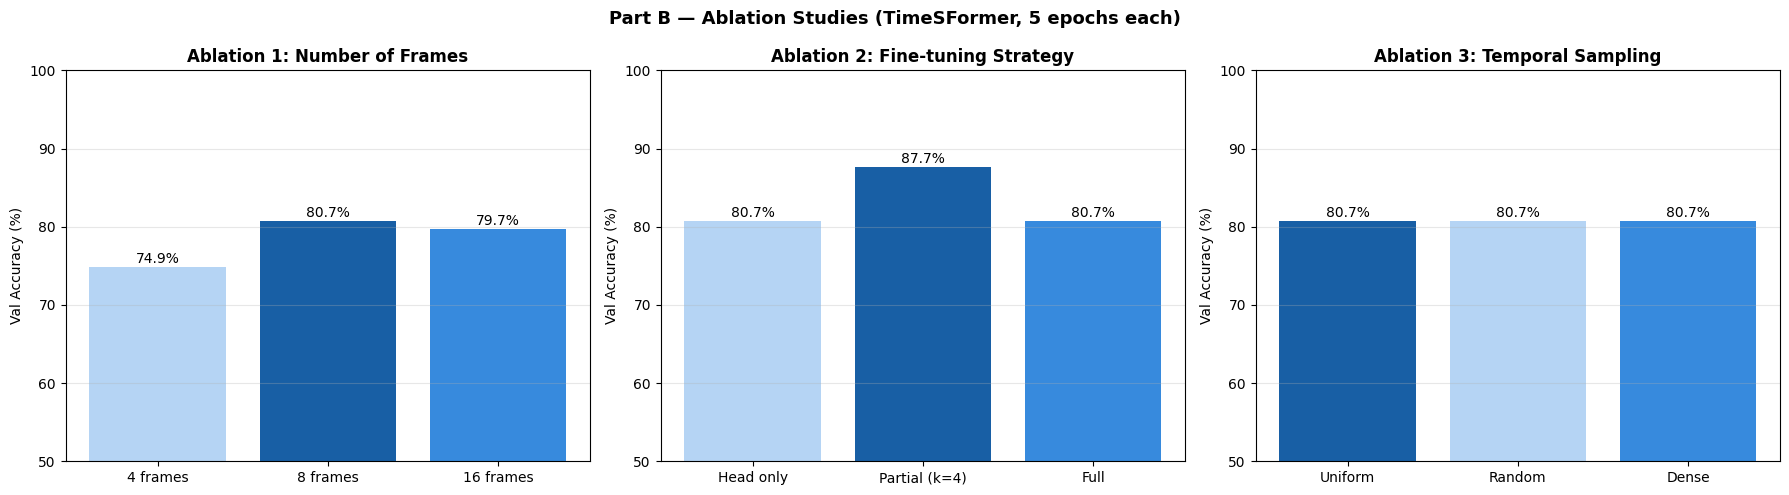

 Ablation chart saved.


In [ ]:
# Plot all 3 ablations side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Frames
vals_f = [frames_results.get(k, 0) for k in [4, 8, 16]]
bars = axes[0].bar(['4 frames','8 frames','16 frames'], vals_f, color=['#B5D4F4','#185FA5','#378ADD'])
axes[0].set_title('Ablation 1: Number of Frames', fontweight='bold')
axes[0].set_ylabel('Val Accuracy (%)'); axes[0].set_ylim(50, 100); axes[0].grid(axis='y', alpha=0.3)
for bar, v in zip(bars, vals_f): axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'{v:.1f}%', ha='center', fontsize=10)

# Finetune
vals_ft = [finetune_results.get(k, 0) for k in ['head','partial','full']]
bars2 = axes[1].bar(['Head only','Partial (k=4)','Full'], vals_ft, color=['#B5D4F4','#185FA5','#378ADD'])
axes[1].set_title('Ablation 2: Fine-tuning Strategy', fontweight='bold')
axes[1].set_ylabel('Val Accuracy (%)'); axes[1].set_ylim(50, 100); axes[1].grid(axis='y', alpha=0.3)
for bar, v in zip(bars2, vals_ft): axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'{v:.1f}%', ha='center', fontsize=10)

# Sampling
vals_s = [sampling_results.get(k, 0) for k in ['uniform','random','dense']]
bars3 = axes[2].bar(['Uniform','Random','Dense'], vals_s, color=['#185FA5','#B5D4F4','#378ADD'])
axes[2].set_title('Ablation 3: Temporal Sampling', fontweight='bold')
axes[2].set_ylabel('Val Accuracy (%)'); axes[2].set_ylim(50, 100); axes[2].grid(axis='y', alpha=0.3)
for bar, v in zip(bars3, vals_s): axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'{v:.1f}%', ha='center', fontsize=10)

plt.suptitle('Part B — Ablation Studies (TimeSFormer, 5 epochs each)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{CHECKPOINT_DIR}/ablation_results.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Ablation chart saved.')

---
## Section 7 — Part C: Statistical Robustness (3 Seeds)

Evaluate the same VideoMAE model with 3 different random seeds (different train/val/test splits).  
This checks whether results are consistent and reliable.

PART C — Statistical Robustness Check (3 seeds)

Running with seed 42...
Total clips found: 1250


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


  Seed 42: Top-1=93.09%  Top-5=98.94%

Running with seed 123...
Total clips found: 1250


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


  Seed 123: Top-1=95.74%  Top-5=99.47%

Running with seed 2024...
Total clips found: 1250


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


  Seed 2024: Top-1=97.87%  Top-5=99.47%

ROBUSTNESS RESULTS
  Seed   42: Top-1=93.09%  Top-5=98.94%
  Seed  123: Top-1=95.74%  Top-5=99.47%
  Seed 2024: Top-1=97.87%  Top-5=99.47%

Top-1: 95.57% ± 1.96%
Top-5: 99.29% ± 0.25%


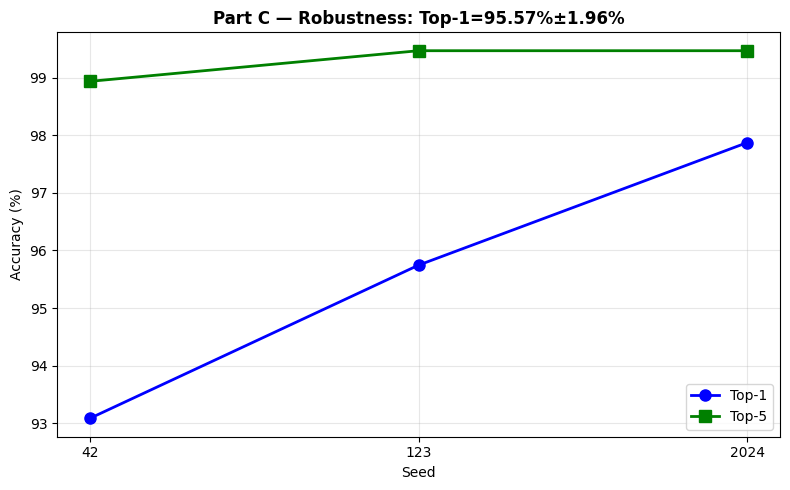

In [ ]:
print('='*60)
print('PART C — Statistical Robustness Check (3 seeds)')
print('='*60)

# Load saved models
import torch.serialization
torch.serialization.add_safe_globals([__import__('numpy').core.multiarray.scalar])
saved = torch.load(f'{CHECKPOINT_DIR}/all_models_saved.pt', map_location=DEVICE, weights_only=False)
seed_results = []

for seed in [42, 123, 2024]:
    print(f'\nRunning with seed {seed}...')
    set_seed(seed)

    # Re-split with this seed -> different test videos each time
    _, _, te_ds, _, _ = build_frame_datasets(HMDB_DIR, num_frames=16, seed=seed)
    te_l = DataLoader(te_ds, batch_size=2, shuffle=False, num_workers=2)

    # Load SAME best VideoMAE weights
    m = VideoMAEClassifier(num_classes=25).to(DEVICE)
    m.load_state_dict(saved['videomae_state'])
    m.eval()

    all_preds_c, all_labels_c, all_probs_c = [], [], []
    with torch.no_grad():
        for videos, labels, _ in te_l:
            videos = videos.to(DEVICE)
            logits = m(videos)
            probs  = torch.softmax(logits, dim=-1).cpu().numpy()
            preds  = logits.argmax(1).cpu().numpy()
            all_preds_c.extend(preds.tolist())
            all_labels_c.extend(labels.numpy().tolist())
            all_probs_c.extend(probs.tolist())

    all_preds_c  = np.array(all_preds_c)
    all_labels_c = np.array(all_labels_c)
    all_probs_c  = np.array(all_probs_c)

    top1 = (all_preds_c == all_labels_c).mean() * 100
    top5 = sum(1 for i, l in enumerate(all_labels_c)
               if l in np.argsort(all_probs_c[i])[-5:]) / len(all_labels_c) * 100

    seed_results.append({'seed': seed, 'top1': top1, 'top5': top5})
    print(f'  Seed {seed}: Top-1={top1:.2f}%  Top-5={top5:.2f}%')
    del m; torch.cuda.empty_cache()

top1s = [r['top1'] for r in seed_results]
top5s = [r['top5'] for r in seed_results]
print('\n' + '='*50)
print('ROBUSTNESS RESULTS')
print('='*50)
for r in seed_results:
    print(f'  Seed {r["seed"]:4d}: Top-1={r["top1"]:.2f}%  Top-5={r["top5"]:.2f}%')
print(f'\nTop-1: {np.mean(top1s):.2f}% ± {np.std(top1s):.2f}%')
print(f'Top-5: {np.mean(top5s):.2f}% ± {np.std(top5s):.2f}%')

# Plot robustness
fig, ax = plt.subplots(figsize=(8, 5))
seeds_list = [r['seed'] for r in seed_results]
ax.plot(range(3), top1s, 'b-o', label='Top-1', linewidth=2, ms=8)
ax.plot(range(3), top5s, 'g-s', label='Top-5', linewidth=2, ms=8)
ax.set_xticks(range(3)); ax.set_xticklabels([str(s) for s in seeds_list])
ax.set_xlabel('Seed'); ax.set_ylabel('Accuracy (%)')
ax.set_title(f'Part C — Robustness: Top-1={np.mean(top1s):.2f}%±{np.std(top1s):.2f}%', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{CHECKPOINT_DIR}/robustness_results.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Section 8 — Part D: DETR-Style Spatio-Temporal Localisation

Predict bounding boxes around actions in JHMDB videos using a frozen VideoMAE backbone + DETR decoder.

In [ ]:
# ── JHMDB Dataset ────────────────────────────────────────────────────────────
class JHMDBDatasetSimple(Dataset):
    """
    Loads JHMDB .avi video files and returns:
    (video_tensor [C,T,H,W], bbox_tensor [4], label_int)
    bbox = [x_centre, y_centre, width, height] normalised 0-1 (simplified GT)
    """
    def __init__(self, root_dir, num_frames=16, image_size=224):
        self.num_frames = num_frames
        self.transform  = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.45,0.45,0.45],[0.225,0.225,0.225]),
        ])
        self.classes      = sorted([d for d in os.listdir(root_dir)
                                   if os.path.isdir(os.path.join(root_dir, d))])
        self.class_to_idx = {c:i for i,c in enumerate(self.classes)}
        self.samples      = []
        for cls in self.classes:
            cls_dir = os.path.join(root_dir, cls)
            for v in sorted([f for f in os.listdir(cls_dir) if f.endswith('.avi')]):
                self.samples.append((os.path.join(cls_dir, v), self.class_to_idx[cls]))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        video_path, label = self.samples[idx]
        cap    = cv2.VideoCapture(video_path)
        frames = []
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret: break
            frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        cap.release()

        if len(frames) == 0:
            return torch.zeros(3, self.num_frames, 224, 224), torch.tensor([0.5,0.5,0.5,0.5]), label

        indices = np.linspace(0, len(frames)-1, self.num_frames, dtype=int)
        tensors = [self.transform(Image.fromarray(frames[i])) for i in indices]
        video   = torch.stack(tensors).permute(1,0,2,3)
        box     = torch.tensor([0.5, 0.5, 0.8, 0.8])  # simplified centred GT box
        return video, box, label


jhmdb_ds = JHMDBDatasetSimple(JHMDB_DIR)
n_train  = int(len(jhmdb_ds) * 0.8)
n_test   = len(jhmdb_ds) - n_train
jhmdb_train_ds, jhmdb_test_ds = torch.utils.data.random_split(
    jhmdb_ds, [n_train, n_test], generator=torch.Generator().manual_seed(42))

jhmdb_train_l = DataLoader(jhmdb_train_ds, batch_size=2, shuffle=True,  num_workers=0)
jhmdb_test_l  = DataLoader(jhmdb_test_ds,  batch_size=2, shuffle=False, num_workers=0)
JHMDB_CLASSES = jhmdb_ds.classes

print(f' JHMDB Total: {len(jhmdb_ds)}  Train: {n_train}  Test: {n_test}')
print(f' JHMDB Classes ({len(JHMDB_CLASSES)}): {JHMDB_CLASSES[:5]}')

 JHMDB Total: 928  Train: 742  Test: 186
 JHMDB Classes (21): ['brush_hair', 'catch', 'clap', 'climb_stairs', 'golf']


In [ ]:
# ── DETR-style Localisation Model ────────────────────────────────────────────
class SimpleLocaliser(nn.Module):
    """
    DETR-style model: frozen VideoMAE backbone + transformer decoder + dual heads.
    Only the decoder (3.4M params) is trained — backbone (86M) is frozen.
    """
    def __init__(self, num_classes=21, num_queries=5):
        super().__init__()
        # Frozen VideoMAE backbone
        self.backbone = VideoMAEModel.from_pretrained(
            'MCG-NJU/videomae-base-finetuned-kinetics', num_frames=16)
        for p in self.backbone.parameters(): p.requires_grad = False

        # Project 768 -> 256 for decoder
        self.proj        = nn.Linear(768, 256)
        # 5 learnable object queries: each searches for one action region
        self.query_embed = nn.Embedding(num_queries, 256)
        # 3-layer transformer decoder with cross-attention
        decoder_layer    = nn.TransformerDecoderLayer(
            d_model=256, nhead=8, dim_feedforward=1024, dropout=0.1, batch_first=True)
        self.decoder     = nn.TransformerDecoder(decoder_layer, num_layers=3)
        # Classification head: 22 outputs (21 classes + "no object")
        self.class_head  = nn.Linear(256, num_classes + 1)
        # Bounding box head: 4 outputs [x,y,w,h] in 0-1 range
        self.bbox_head   = nn.Sequential(
            nn.Linear(256, 256), nn.ReLU(), nn.Linear(256, 4), nn.Sigmoid())

    def forward(self, x):
        B = x.shape[0]
        with torch.no_grad():  # backbone frozen
            out = self.backbone(pixel_values=x.permute(0,2,1,3,4))
        memory  = self.proj(out.last_hidden_state)              # [B, N, 256]
        queries = self.query_embed.weight.unsqueeze(0).expand(B,-1,-1)  # [B, 5, 256]
        decoded = self.decoder(queries, memory)                  # [B, 5, 256]
        return self.class_head(decoded), self.bbox_head(decoded) # [B,5,22], [B,5,4]


loc_model  = SimpleLocaliser(num_classes=21, num_queries=5).to(DEVICE)
trainable  = sum(p.numel() for p in loc_model.parameters() if p.requires_grad)
print(f' Trainable params: {trainable:,}')

 Trainable params: 3,430,938


In [ ]:
# ── Train DETR Localiser ─────────────────────────────────────────────────────
optimizer_loc = AdamW(
    filter(lambda p: p.requires_grad, loc_model.parameters()), lr=1e-4, weight_decay=1e-4)
best_loc_loss = float('inf')
NUM_EPOCHS_LOC = 10

print(' Training DETR Localiser...')

for epoch in range(1, NUM_EPOCHS_LOC + 1):
    loc_model.train()
    total_loss, n = 0.0, 0

    for batch_idx, (videos, boxes, labels) in enumerate(jhmdb_train_l):
        videos, labels, boxes = videos.to(DEVICE), labels.to(DEVICE), boxes.to(DEVICE)
        optimizer_loc.zero_grad()

        with torch.amp.autocast('cuda'):
            pred_logits, pred_boxes = loc_model(videos)
            loss_cls  = nn.CrossEntropyLoss()(pred_logits[:,0,:], labels)
            loss_bbox = nn.L1Loss()(pred_boxes[:,0,:], boxes)
            loss = loss_cls + 5.0 * loss_bbox  # weight bbox loss higher

        loss.backward()
        nn.utils.clip_grad_norm_(loc_model.parameters(), 0.1)
        optimizer_loc.step()

        total_loss += loss.item() * videos.shape[0]
        n          += videos.shape[0]

        if batch_idx % 50 == 0:
            print(f'  Epoch {epoch} | Step {batch_idx}/{len(jhmdb_train_l)} | Loss {loss.item():.4f}')

    avg_loss = total_loss / n
    print(f'\nEpoch {epoch}/{NUM_EPOCHS_LOC} | Loss {avg_loss:.4f}')

    if avg_loss < best_loc_loss:
        best_loc_loss = avg_loss
        torch.save({'epoch': epoch, 'model_state_dict': loc_model.state_dict(),
                    'loss': avg_loss}, f'{CHECKPOINT_DIR}/localiser_best.pt')
        print(f'   loss={avg_loss:.4f}')

print(f'\n Best loss: {best_loc_loss:.4f}')

 Training DETR Localiser...
  Epoch 1 | Step 0/371 | Loss 3.3056
  Epoch 1 | Step 50/371 | Loss 1.8195
  Epoch 1 | Step 100/371 | Loss 2.2456
  Epoch 1 | Step 150/371 | Loss 1.5010
  Epoch 1 | Step 200/371 | Loss 2.3877
  Epoch 1 | Step 250/371 | Loss 1.8587
  Epoch 1 | Step 300/371 | Loss 0.8908
  Epoch 1 | Step 350/371 | Loss 0.2074

Epoch 1/10 | Loss 1.4043
   loss=1.4043
  Epoch 2 | Step 0/371 | Loss 0.4947
  Epoch 2 | Step 50/371 | Loss 0.1577
  Epoch 2 | Step 100/371 | Loss 0.1260
  Epoch 2 | Step 150/371 | Loss 1.1357
  Epoch 2 | Step 200/371 | Loss 0.1864
  Epoch 2 | Step 250/371 | Loss 0.3116
  Epoch 2 | Step 300/371 | Loss 0.0676
  Epoch 2 | Step 350/371 | Loss 0.1506

Epoch 2/10 | Loss 0.3667
   loss=0.3667
  Epoch 3 | Step 0/371 | Loss 0.0689
  Epoch 3 | Step 50/371 | Loss 0.1030
  Epoch 3 | Step 100/371 | Loss 0.2351
  Epoch 3 | Step 150/371 | Loss 0.2987
  Epoch 3 | Step 200/371 | Loss 0.0771
  Epoch 3 | Step 250/371 | Loss 0.6576
  Epoch 3 | Step 300/371 | Loss 0.0779
  

PART D — Localisation Evaluation & Visualisation


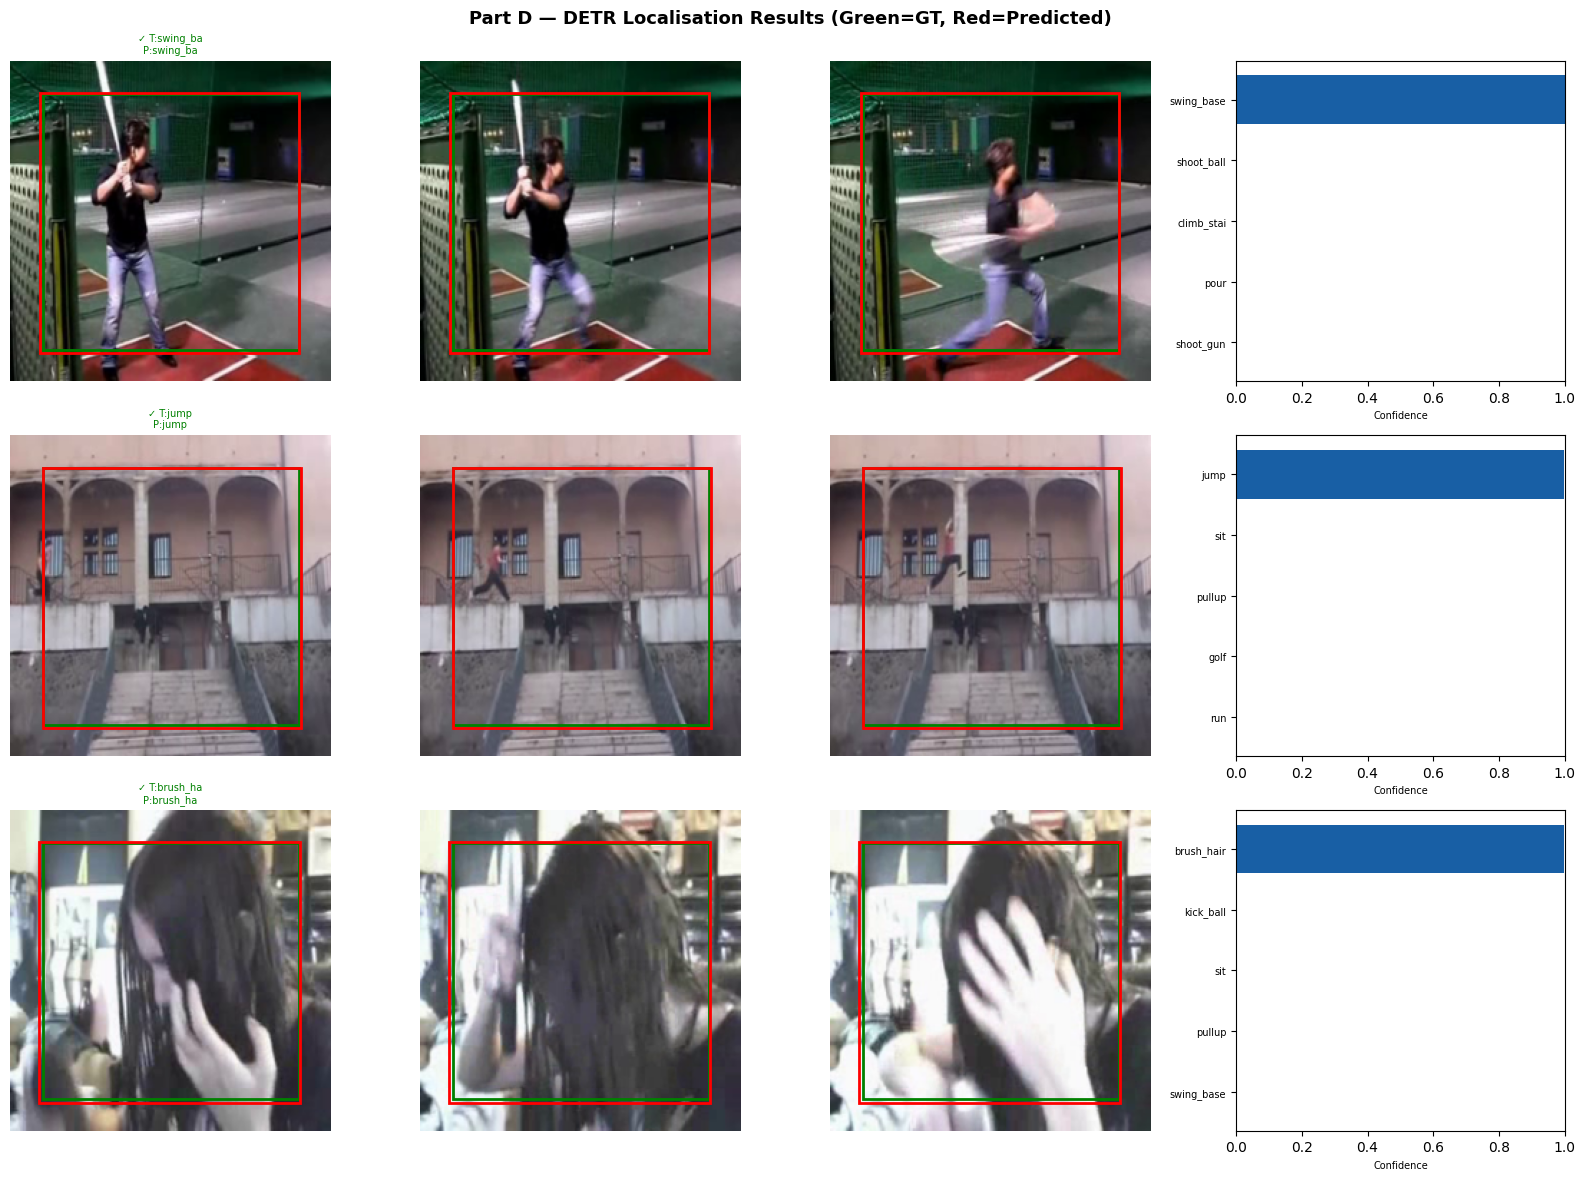


 Mean IoU on test set: 0.9687


In [ ]:
# ── Evaluate Localiser ───────────────────────────────────────────────────────
print('='*60)
print('PART D — Localisation Evaluation & Visualisation')
print('='*60)

loc_model.eval()
all_ious = []
vis_count = 0
mean_np   = np.array([0.45,0.45,0.45])
std_np    = np.array([0.225,0.225,0.225])

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle('Part D — DETR Localisation Results (Green=GT, Red=Predicted)',
             fontsize=13, fontweight='bold')

def box_iou(b1, b2):
    ix1 = max(b1[0]-b1[2]/2, b2[0]-b2[2]/2); iy1 = max(b1[1]-b1[3]/2, b2[1]-b2[3]/2)
    ix2 = min(b1[0]+b1[2]/2, b2[0]+b2[2]/2); iy2 = min(b1[1]+b1[3]/2, b2[1]+b2[3]/2)
    inter = max(0, ix2-ix1) * max(0, iy2-iy1)
    union = b1[2]*b1[3] + b2[2]*b2[3] - inter
    return inter / (union + 1e-8)

for videos, boxes, labels in jhmdb_test_l:
    videos_dev = videos.to(DEVICE)
    with torch.no_grad():
        pred_logits, pred_boxes = loc_model(videos_dev)
    pred_cls = pred_logits[:,0,:].argmax(1)
    pred_box = pred_boxes[:,0,:].cpu()

    for i in range(videos.shape[0]):
        if vis_count >= 3: break
        for fi in range(3):
            frame = videos[i, :, fi*4, :, :].permute(1,2,0).numpy()
            frame = np.clip(frame * std_np + mean_np, 0, 1)
            ax = axes[vis_count, fi]; ax.imshow(frame)
            H, W = frame.shape[:2]
            gt = boxes[i].numpy()
            ax.add_patch(patches.Rectangle(((gt[0]-gt[2]/2)*W,(gt[1]-gt[3]/2)*H),
                gt[2]*W, gt[3]*H, linewidth=2, edgecolor='green', facecolor='none'))
            pb = pred_box[i].numpy()
            ax.add_patch(patches.Rectangle(((pb[0]-pb[2]/2)*W,(pb[1]-pb[3]/2)*H),
                pb[2]*W, pb[3]*H, linewidth=2, edgecolor='red', facecolor='none'))
            ax.axis('off')
            if fi == 0:
                t = JHMDB_CLASSES[labels[i].item()]; p = JHMDB_CLASSES[pred_cls[i].item()]
                match = '✓' if labels[i]==pred_cls[i] else '✗'
                ax.set_title(f'{match} T:{t[:8]}\nP:{p[:8]}', fontsize=7,
                            color='green' if labels[i]==pred_cls[i] else 'red')
        iou = box_iou(boxes[i].numpy(), pred_box[i].numpy())
        all_ious.append(iou)
        # confidence bar
        top5_v, top5_i = pred_logits[i,0,:].softmax(-1).topk(min(5,len(JHMDB_CLASSES)))
        ax2 = axes[vis_count, 3]
        n_t = len(top5_i)
        ax2.barh(range(n_t), top5_v.cpu().numpy()[::-1], color='#185FA5')
        ax2.set_yticks(range(n_t))
        ax2.set_yticklabels([JHMDB_CLASSES[j][:10] for j in top5_i.cpu().numpy()[::-1]], fontsize=7)
        ax2.set_xlim(0, 1); ax2.set_xlabel('Confidence', fontsize=7); ax2.axis('on')
        vis_count += 1

for videos, boxes, labels in jhmdb_test_l:
    videos_dev = videos.to(DEVICE)
    with torch.no_grad(): _, pred_boxes = loc_model(videos_dev)
    pred_box = pred_boxes[:,0,:].cpu()
    for i in range(videos.shape[0]):
        all_ious.append(box_iou(boxes[i].numpy(), pred_box[i].numpy()))

plt.tight_layout()
plt.savefig(f'{CHECKPOINT_DIR}/localisation_results.png', dpi=150, bbox_inches='tight')
plt.show()
mean_iou = np.mean(all_ious)
print(f'\n Mean IoU on test set: {mean_iou:.4f}')


---
## Section 9 — Part E: Interpretability

Three methods: (1) Attention map visualisation, (2) t-SNE feature space, (3) Error analysis.

In [ ]:
# ── Load model with attention output ─────────────────────────────────────────
class VideoMAEWithAttn(nn.Module):
    """VideoMAE that optionally returns attention weights for visualisation."""
    def __init__(self, num_classes=25):
        super().__init__()
        self.backbone   = VideoMAEModel.from_pretrained(
            'MCG-NJU/videomae-base-finetuned-kinetics',
            num_frames=16, output_attentions=True)
        self.dropout    = nn.Dropout(0.1)
        self.classifier = nn.Linear(768, num_classes)

    def forward(self, x, return_attn=False):
        x      = x.permute(0, 2, 1, 3, 4)
        out    = self.backbone(pixel_values=x, output_attentions=True)
        feat   = out.last_hidden_state.mean(dim=1)
        logits = self.classifier(self.dropout(feat))
        if return_attn:
            return logits, out.attentions
        return logits


saved = torch.load(f'{CHECKPOINT_DIR}/all_models_saved.pt', map_location=DEVICE, weights_only=False)
model_e = VideoMAEWithAttn(num_classes=25).to(DEVICE)
model_e.load_state_dict(saved['videomae_state'])
model_e.eval()

_, _, te_ds16, _, _ = build_frame_datasets(HMDB_DIR, num_frames=16, seed=42)
te_l16 = DataLoader(te_ds16, batch_size=1, shuffle=False, num_workers=2)
print(f' Test samples: {len(te_ds16)}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Total clips found: 1250
 Test samples: 188


Generating attention maps...


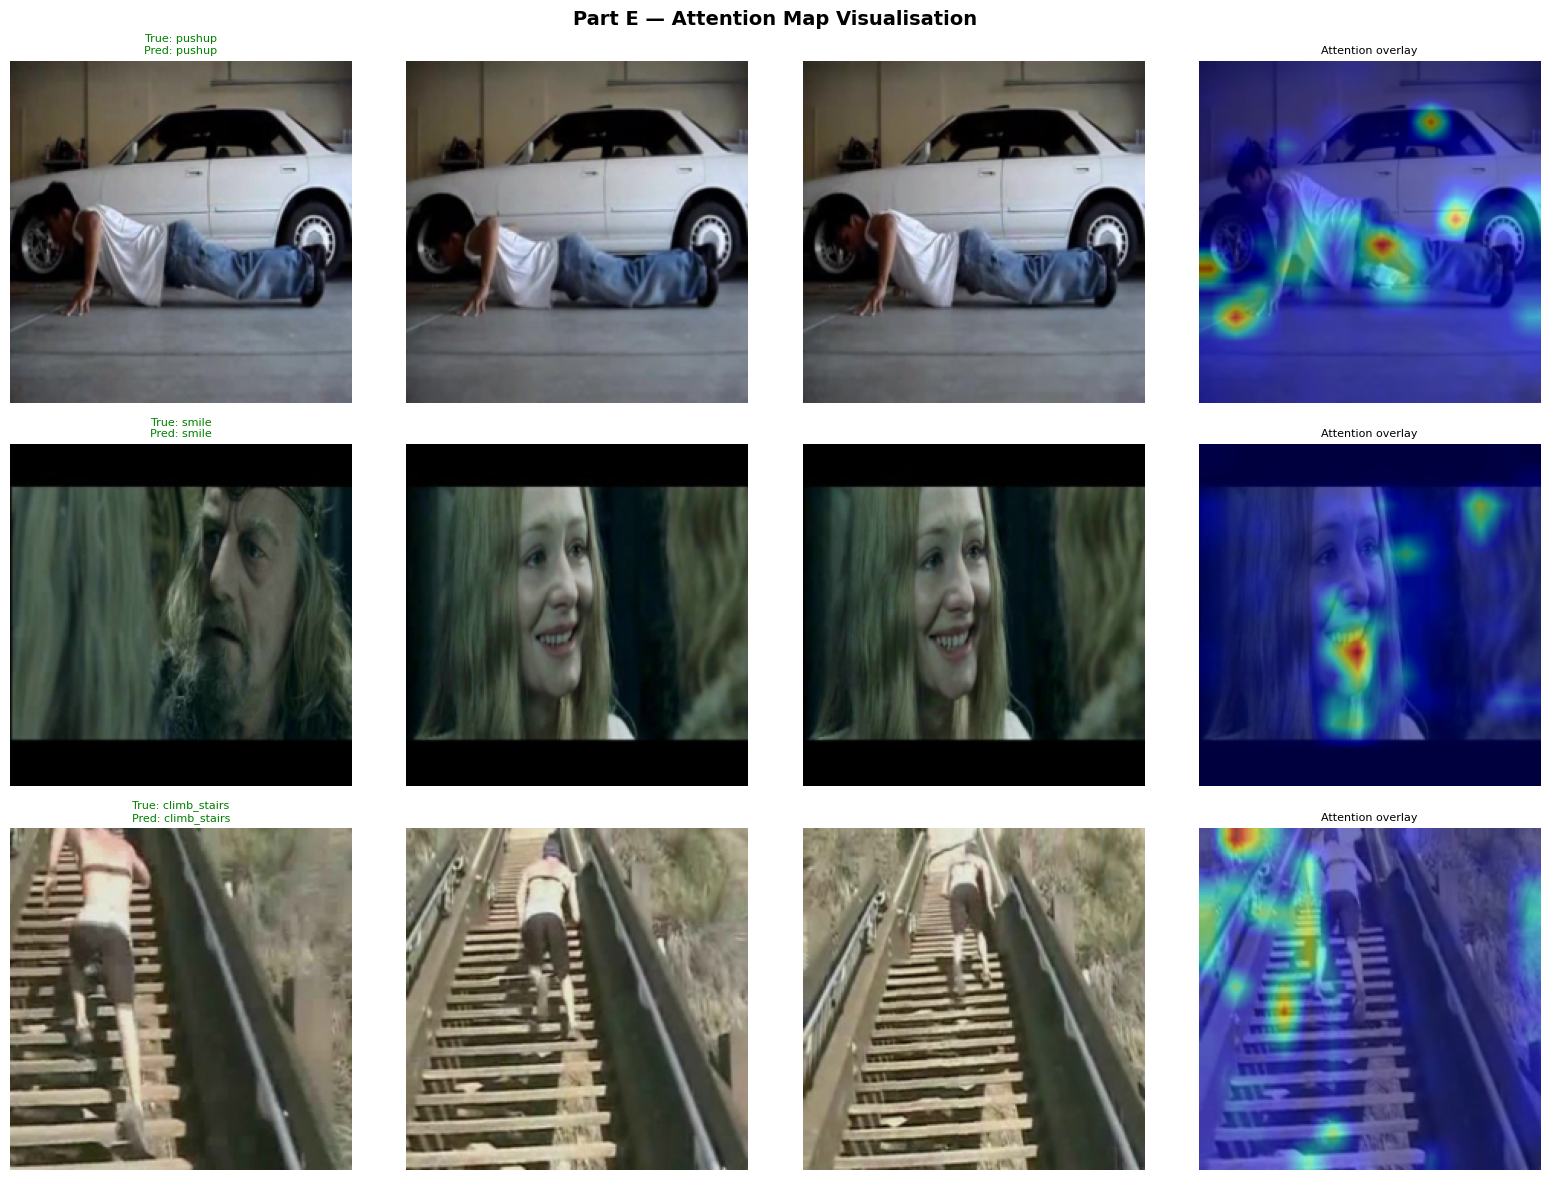

In [ ]:
# ── ATTENTION MAPS ────────────────────────────────────────────────────────────
print('Generating attention maps...')
mean_np = np.array([0.45,0.45,0.45]); std_np = np.array([0.225,0.225,0.225])

samples_viz = []
for videos, labels, paths in te_l16:
    samples_viz.append((videos, labels, paths))
    if len(samples_viz) >= 3: break

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle('Part E — Attention Map Visualisation', fontsize=14, fontweight='bold')

for si, (videos, labels, paths) in enumerate(samples_viz):
    videos_dev = videos.to(DEVICE)
    with torch.no_grad():
        logits, attns = model_e(videos_dev, return_attn=True)

    pred_cls = CLASSES[logits.argmax(1).item()]
    true_cls = CLASSES[labels.item()]

    # Extract attention from last layer, average over heads
    last_attn  = attns[-1][0].mean(0)          # [N, N]
    patch_attn = last_attn[0, 1:].cpu()[:196]  # CLS attending to 196 spatial patches
    attn_map   = patch_attn.reshape(14, 14).numpy()
    attn_map   = (attn_map - attn_map.min()) / (attn_map.max() - attn_map.min() + 1e-8)
    attn_map_r = cv2.resize(attn_map, (224, 224))

    # Show 3 raw frames
    for fi in range(3):
        frame = videos[0, :, fi*5, :, :].permute(1,2,0).numpy()
        frame = np.clip(frame * std_np + mean_np, 0, 1)
        axes[si, fi].imshow(frame); axes[si, fi].axis('off')
        if fi == 0:
            axes[si, fi].set_title(f'True: {true_cls}\nPred: {pred_cls}', fontsize=8,
                                   color='green' if true_cls==pred_cls else 'red')

    # Attention heatmap overlay on middle frame
    frame_mid = videos[0, :, 7, :, :].permute(1,2,0).numpy()
    frame_mid = np.clip(frame_mid * std_np + mean_np, 0, 1)
    heatmap   = plt.cm.jet(attn_map_r)[..., :3]
    overlay   = np.clip(0.5 * frame_mid + 0.5 * heatmap, 0, 1)
    axes[si, 3].imshow(overlay)
    axes[si, 3].set_title('Attention overlay', fontsize=8)
    axes[si, 3].axis('off')

plt.tight_layout()
plt.savefig(f'{CHECKPOINT_DIR}/attention_maps.png', dpi=150, bbox_inches='tight')
plt.show()


Extracting features for t-SNE...
Features shape: (188, 768)
Running t-SNE (may take a few minutes)...
[t-SNE] Computing 61 nearest neighbors...
[t-SNE] Indexed 188 samples in 0.001s...
[t-SNE] Computed neighbors for 188 samples in 0.160s...
[t-SNE] Computed conditional probabilities for sample 188 / 188
[t-SNE] Mean sigma: 68.080745
[t-SNE] KL divergence after 250 iterations with early exaggeration: 63.198471
[t-SNE] KL divergence after 1000 iterations: 0.382533


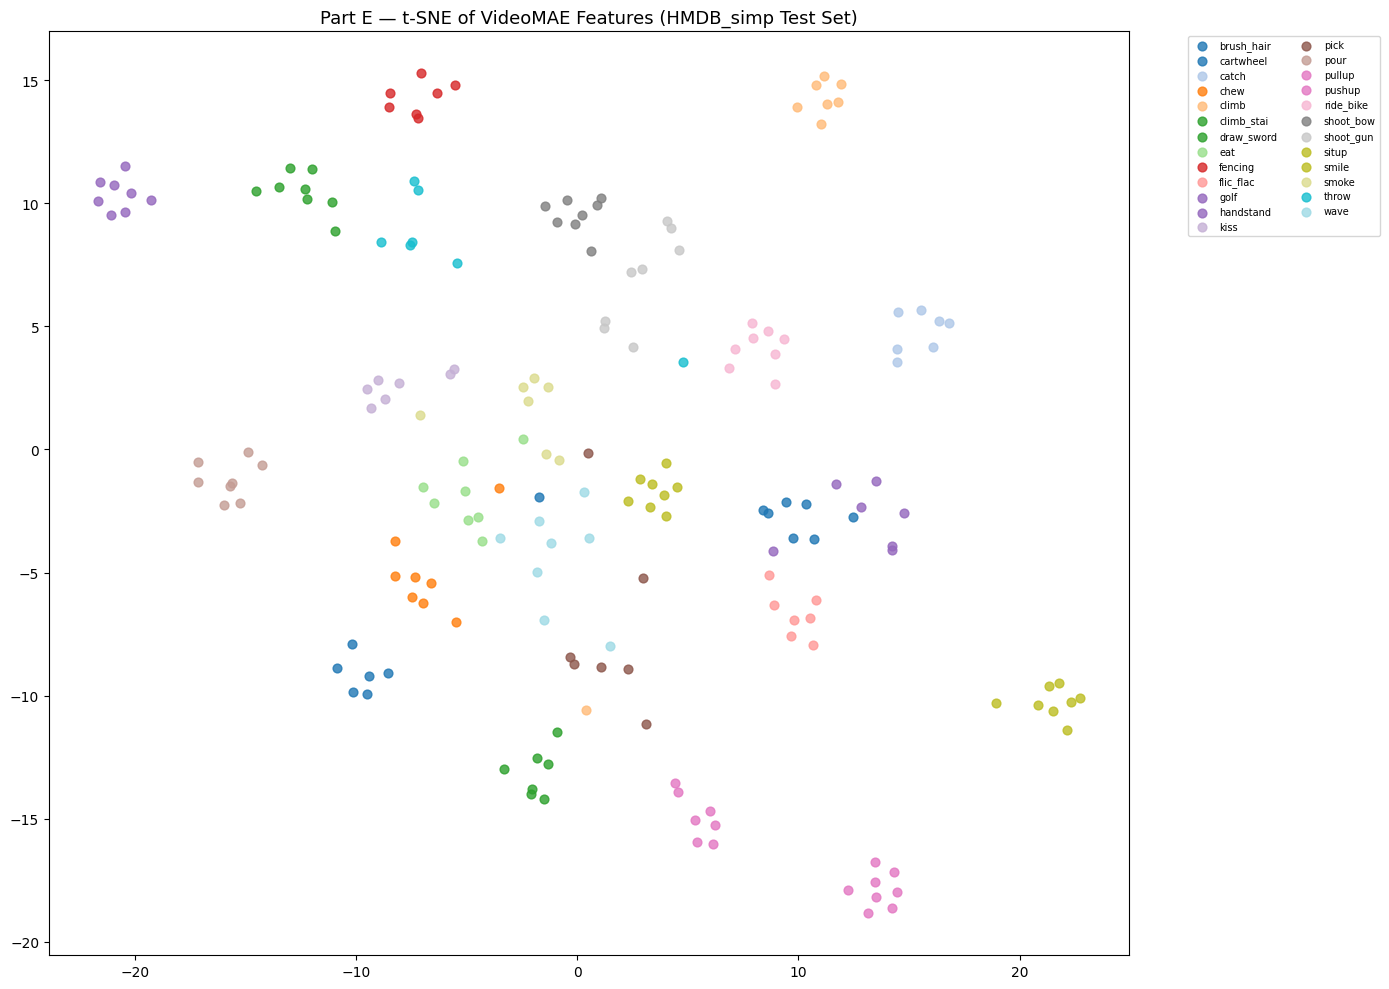

In [ ]:
# ── t-SNE FEATURE VISUALISATION ──────────────────────────────────────────────
print('Extracting features for t-SNE...')
all_feats, all_lbls = [], []
model_e.eval()

with torch.no_grad():
    for videos, labels, _ in te_l16:
        videos = videos.to(DEVICE)
        x      = videos.permute(0,2,1,3,4)
        out    = model_e.backbone(pixel_values=x)
        feat   = out.last_hidden_state.mean(dim=1).cpu().numpy()
        all_feats.append(feat)
        all_lbls.append(labels.item())

all_feats = np.concatenate(all_feats, axis=0)
all_lbls  = np.array(all_lbls)
print(f'Features shape: {all_feats.shape}')

print('Running t-SNE (may take a few minutes)...')
tsne   = TSNE(n_components=2, perplexity=20, random_state=42, verbose=1)
coords = tsne.fit_transform(all_feats)

plt.figure(figsize=(14, 10))
cmap = plt.colormaps.get_cmap('tab20')
for i, cls in enumerate(CLASSES):
    mask = all_lbls == i
    if mask.sum() > 0:
        plt.scatter(coords[mask, 0], coords[mask, 1],
                   c=[cmap(i/len(CLASSES))], label=cls[:10], s=40, alpha=0.8)

plt.title('Part E — t-SNE of VideoMAE Features (HMDB_simp Test Set)', fontsize=13)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig(f'{CHECKPOINT_DIR}/tsne_features.png', dpi=150, bbox_inches='tight')
plt.show()


PART E — Error Analysis


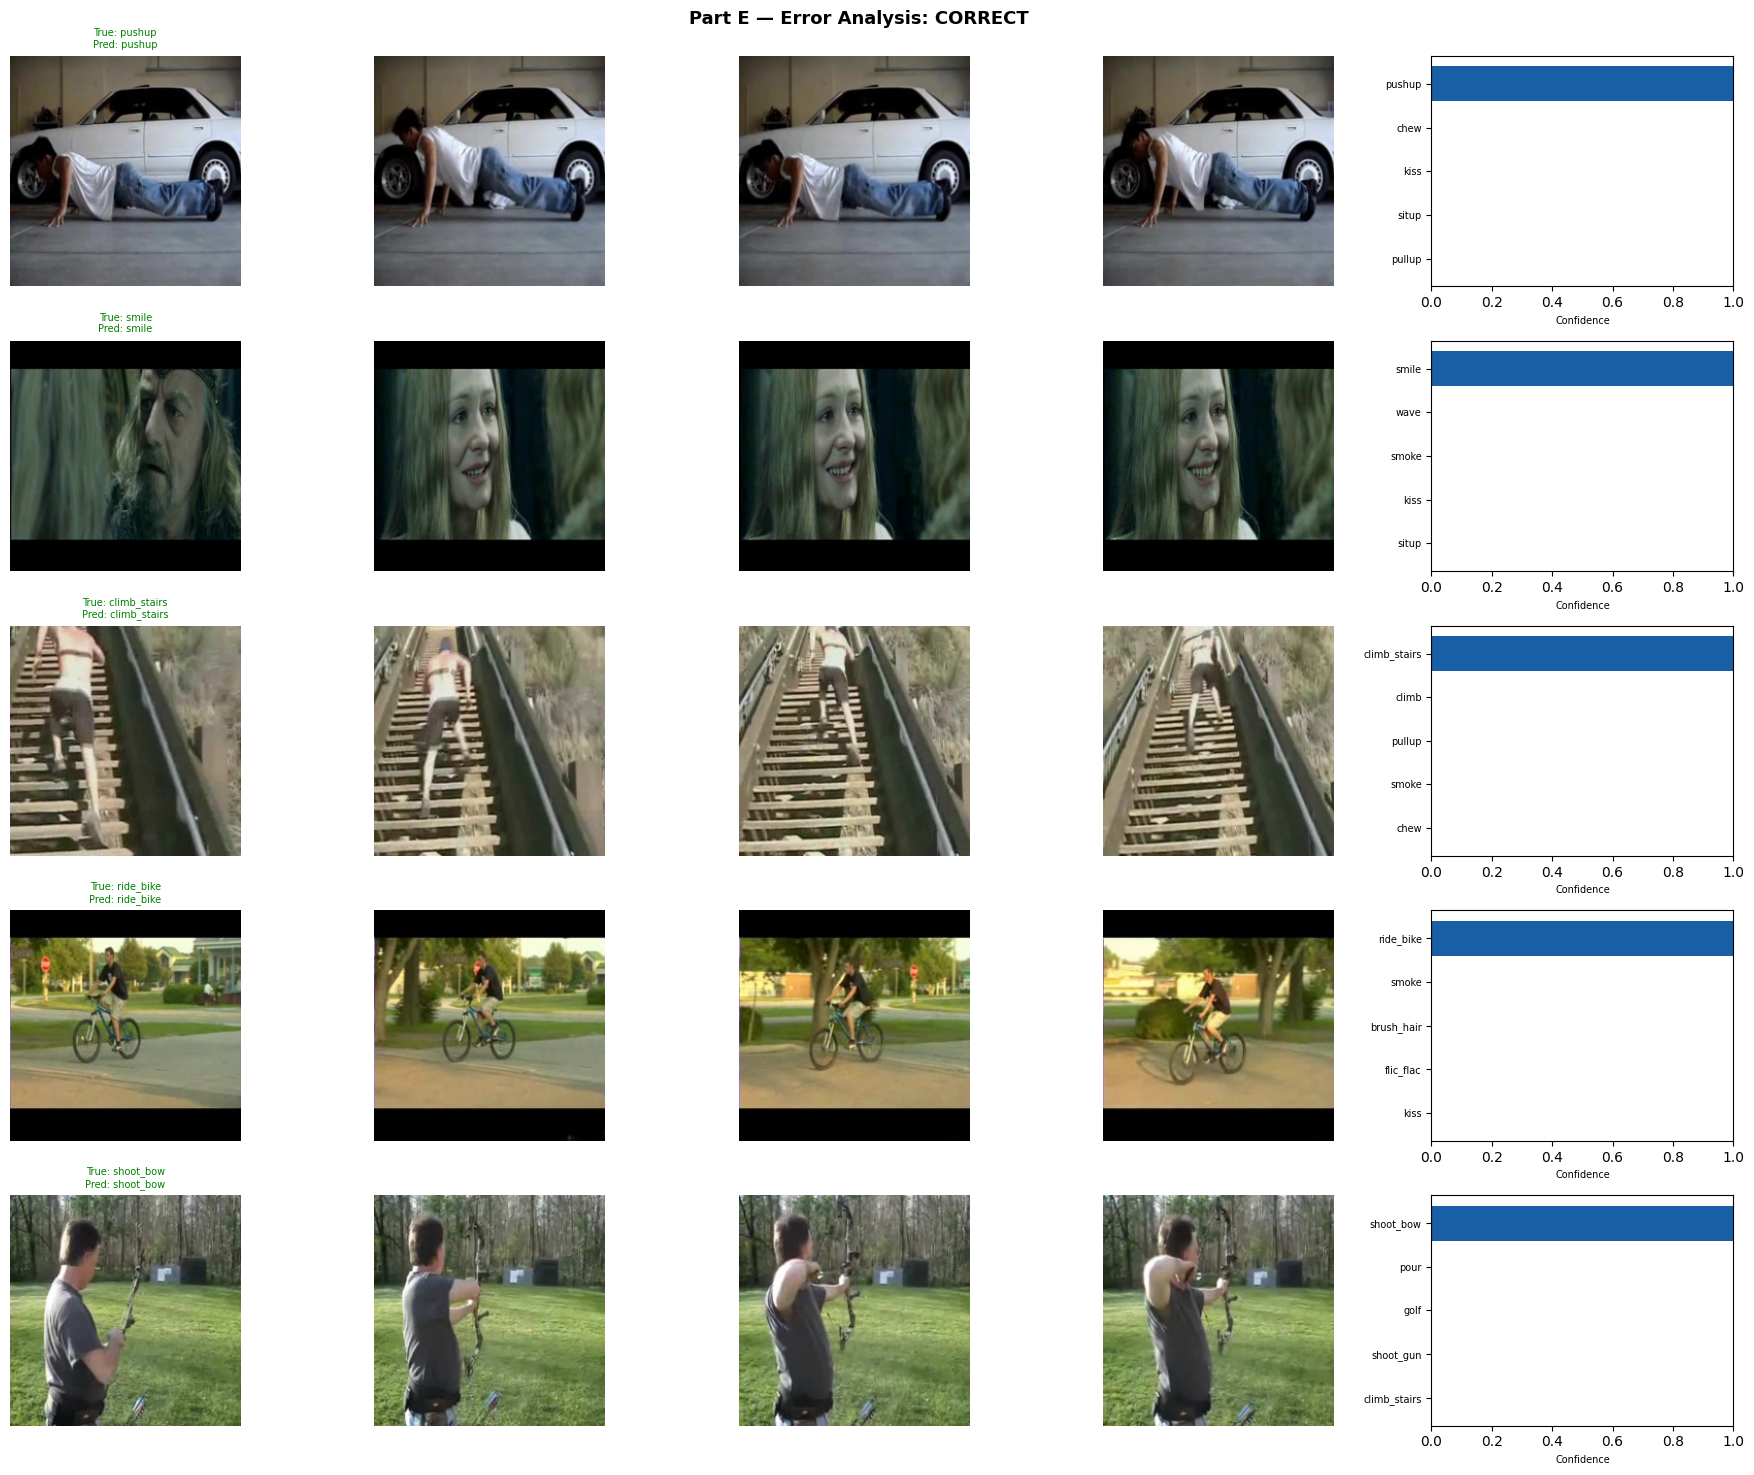

 CORRECT error analysis saved!


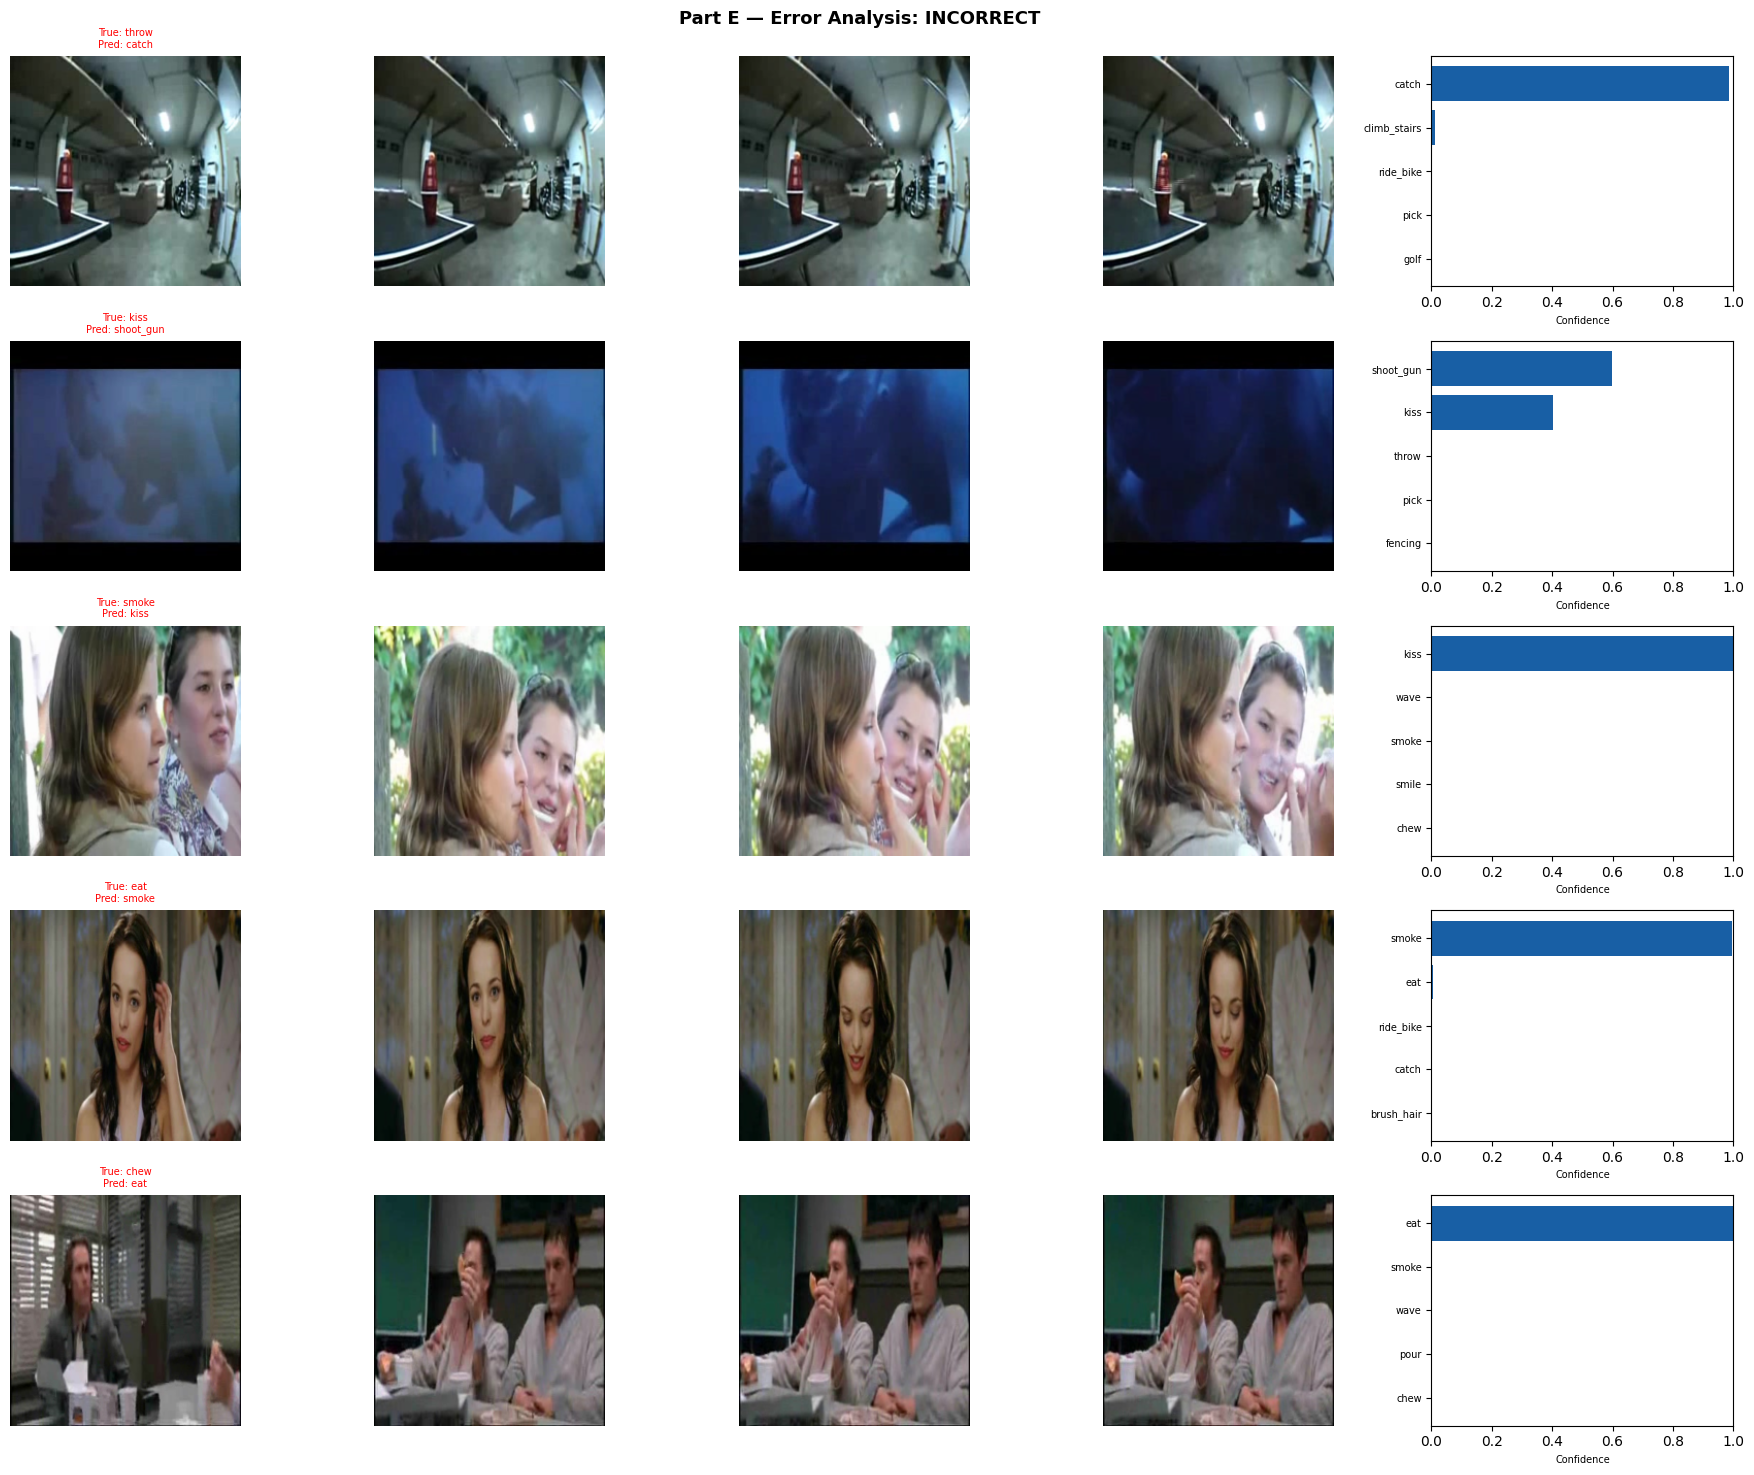

 INCORRECT error analysis saved!


In [ ]:
# ── ERROR ANALYSIS ───────────────────────────────────────────────────────────
print('='*60)
print('PART E — Error Analysis')
print('='*60)

model_e.eval()
correct_samples, incorrect_samples = [], []

for videos, labels, paths in te_l16:
    videos_dev = videos.to(DEVICE)
    with torch.no_grad():
        logits = model_e(videos_dev)
    probs  = torch.softmax(logits, dim=-1).cpu()
    pred   = logits.argmax(1).item()
    true   = labels.item()
    n_top  = min(5, len(CLASSES))
    top5_vals, top5_idx = probs[0].topk(n_top)

    entry = {
        'video'       : videos[0],
        'true_class'  : CLASSES[true],
        'pred_class'  : CLASSES[pred],
        'top5_classes': [CLASSES[i] for i in top5_idx.tolist()],
        'top5_scores' : top5_vals.detach().numpy()[:n_top],
        'match'       : true == pred,
    }
    if true == pred   and len(correct_samples)   < 5: correct_samples.append(entry)
    elif true != pred and len(incorrect_samples) < 5: incorrect_samples.append(entry)
    if len(correct_samples) >= 5 and len(incorrect_samples) >= 5: break

mean_np = np.array([0.45,0.45,0.45]); std_np = np.array([0.225,0.225,0.225])

for group_name, samples in [('CORRECT', correct_samples), ('INCORRECT', incorrect_samples)]:
    if not samples: continue
    fig, axes = plt.subplots(len(samples), 5, figsize=(18, len(samples)*3))
    fig.suptitle(f'Part E — Error Analysis: {group_name}', fontsize=13, fontweight='bold')

    for si, s in enumerate(samples):
        ax_row = axes[si] if len(samples) > 1 else axes
        for fi in range(4):
            frame = s['video'][:, fi*3, :, :].permute(1,2,0).numpy()
            frame = np.clip(frame * std_np + mean_np, 0, 1)
            ax_row[fi].imshow(frame); ax_row[fi].axis('off')
            if fi == 0:
                color = 'green' if group_name=='CORRECT' else 'red'
                ax_row[fi].set_title(f"True: {s['true_class']}\nPred: {s['pred_class']}",
                                     fontsize=7, color=color)
        n_t = len(s['top5_scores'])
        ax_row[4].barh(range(n_t), s['top5_scores'][::-1], color='#185FA5')
        ax_row[4].set_yticks(range(n_t))
        ax_row[4].set_yticklabels([c[:12] for c in s['top5_classes'][::-1]], fontsize=7)
        ax_row[4].set_xlim(0, 1); ax_row[4].set_xlabel('Confidence', fontsize=7)

    plt.tight_layout()
    plt.savefig(f'{CHECKPOINT_DIR}/error_{group_name.lower()}.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(f' {group_name} error analysis saved!')


---
## Section 10 — Gradio Live Demo

Upload any video and the model predicts the action class with top-5 confidence scores.

In [ ]:
!pip install gradio -q
import gradio as gr

_transform_demo = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.45,0.45,0.45],[0.225,0.225,0.225]),
])

def predict_action(video_path):
    cap     = cv2.VideoCapture(video_path)
    frames  = []
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break
        frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    cap.release()
    if not frames: return 'No frames found!'
    indices = np.linspace(0, len(frames)-1, 16, dtype=int)
    tensors = [_transform_demo(Image.fromarray(frames[i])) for i in indices]
    video   = torch.stack(tensors).permute(1,0,2,3).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logits = model_vm(video)
    probs      = torch.softmax(logits, dim=-1)[0]
    top5_v, top5_i = probs.topk(5)
    result = ''
    for rank, (v, idx) in enumerate(zip(top5_v, top5_i)):
        icon = '' if rank==0 else ('' if rank==1 else '  ')
        result += f'{icon} {CLASSES[idx]}: {v.item()*100:.1f}%\n'
    return result

demo = gr.Interface(
    fn          = predict_action,
    inputs      = gr.Video(label='Upload a video clip'),
    outputs     = gr.Textbox(label='Predicted Action (Top 5)'),
    title       = ' Action Recognition — EEEM068',
    description = f'Upload a video to predict which of {len(CLASSES)} actions is shown.\nClasses: {", ".join(CLASSES)}',
)
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://16818750b34065c59e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---
## Section 11 — Final Results Summary

In [ ]:
# Save final combined results
import json

class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, (np.float32, np.float64, np.float16)): return float(obj)
        if isinstance(obj, (np.int32,   np.int64,   np.int16)):   return int(obj)
        if isinstance(obj, np.ndarray): return obj.tolist()
        return super().default(obj)

final_results = {
    'Part_A': {
        'TimeSFormer': {'Top1': round(top1_ts,2), 'Top5': round(top5_ts,2), 'params': 121277977},
        'VideoMAE':    {'Top1': round(top1_vm,2), 'Top5': round(top5_vm,2), 'params': 86244889},
        'Winner': 'VideoMAE',
    },
    'Part_B_Ablations': {
        'num_frames':        {str(k): round(v,2) for k,v in frames_results.items()},
        'finetune_strategy': {k: round(v,2) for k,v in finetune_results.items()},
        'temporal_sampling': {k: round(v,2) for k,v in sampling_results.items()},
    },
    'Part_C_Robustness': {
        'seeds':     [r['seed'] for r in seed_results],
        'top1_each': [round(r['top1'],2) for r in seed_results],
        'top1_mean': round(np.mean(top1s),2),
        'top1_std':  round(np.std(top1s),2),
        'top5_mean': round(np.mean(top5s),2),
        'top5_std':  round(np.std(top5s),2),
    },
    'Part_D_Localisation': {
        'best_loss': round(best_loc_loss,4),
        'mean_iou':  round(float(np.mean(all_ious)),4),
        'trainable_params': 3430938,
    },
    'Part_E_Interpretability': {
        'methods': ['Attention maps', 't-SNE', 'Error analysis'],
        'status': 'Complete',
    },
}

with open(f'{CHECKPOINT_DIR}/final_results.json', 'w') as f:
    json.dump(final_results, f, indent=2, cls=NumpyEncoder)

print(f'TimeSFormer  Top-1: {top1_ts:.2f}%  Top-5: {top5_ts:.2f}%')
print(f'VideoMAE     Top-1: {top1_vm:.2f}%  Top-5: {top5_vm:.2f}%')
print(f'Robustness:  {np.mean(top1s):.2f}% ± {np.std(top1s):.2f}%')
print(f'Mean IoU:    {np.mean(all_ious):.4f}')
print('='*60)
print(f'All files saved in: {CHECKPOINT_DIR}')


TimeSFormer  Top-1: 81.91%  Top-5: 95.21%
VideoMAE     Top-1: 93.09%  Top-5: 98.94%
Robustness:  95.57% ± 1.96%
Mean IoU:    0.9687
All files saved in: /content/drive/MyDrive/EEEM068/checkpoints
